# USD/TWD 1-min history pull (Twelve Data)

Walks backward from now in 5000-bar pages until the API runs out of data (~2020) or `FLOOR_DATE`.
Free tier: 8 credits/min, 800/day. ~340 calls total, ~45 min. Checkpoints to CSV after every call, so you can interrupt and re-run to resume.

In [ ]:
import os, time, json, math, datetime as dt
from collections import deque
import requests
import pandas as pd

API_KEY    = open("twelvedata.key").read().strip()   # key lives in gitignored file next to notebook
SYMBOL     = "USD/TWD"
INTERVAL   = "1min"
TZ         = "Asia/Taipei"          # all datetimes below are Taipei local
OUTPUTSIZE = 5000                   # max per call on free tier
FLOOR_DATE = pd.Timestamp("2019-01-01")   # stop here even if API still has data

PER_MIN = 8
PER_DAY = 800

OUT_DIR = "data"
OUT_CSV = os.path.join(OUT_DIR, "usdtwd_1m.csv")
os.makedirs(OUT_DIR, exist_ok=True)

URL = "https://api.twelvedata.com/time_series"

In [ ]:
class RateLimiter:
    """Sliding-window limiter: never more than PER_MIN calls in any 60s window."""
    def __init__(self, per_min):
        self.per_min = per_min
        self.calls = deque()
        self.total = 0

    def wait(self):
        now = time.time()
        while self.calls and now - self.calls[0] >= 60:
            self.calls.popleft()
        if len(self.calls) >= self.per_min:
            sleep_for = 60 - (now - self.calls[0]) + 0.2
            time.sleep(max(sleep_for, 0))
        self.calls.append(time.time())
        self.total += 1

    def used_this_minute(self):
        now = time.time()
        return sum(1 for t in self.calls if now - t < 60)


def fetch_page(end_date, limiter):
    """One API call. Returns (df_newest_first, status) where status in {'ok','nodata','daily_limit'}."""
    params = dict(symbol=SYMBOL, interval=INTERVAL, outputsize=OUTPUTSIZE,
                  timezone=TZ, end_date=end_date.strftime("%Y-%m-%d %H:%M:%S"),
                  apikey=API_KEY)
    while True:
        limiter.wait()
        try:
            r = requests.get(URL, params=params, timeout=30).json()
        except Exception as e:
            print(f"    network error: {e}; retrying in 5s")
            time.sleep(5)
            continue

        if r.get("status") == "error":
            msg = r.get("message", "")
            code = r.get("code")
            # both minute and day limits come back as code 429; check the day one FIRST
            # ("You have run out of API credits for the day. ...")
            if code == 429 and "for the day" in msg:
                return None, "daily_limit"
            if code == 429 or "credits for the current minute" in msg:
                # API minute is wall-clock; sleep to next minute boundary
                sleep_for = 60 - (time.time() % 60) + 0.5
                print(f"    minute limit hit; sleeping {sleep_for:.0f}s")
                time.sleep(sleep_for)
                continue
            if code in (400, 404) or "not found" in msg.lower():
                print(f"    API {code}: {msg}")        # a bad symbol/param also lands here
                return None, "nodata"
            raise RuntimeError(f"API error {code}: {msg}")

        vals = r.get("values", [])
        if not vals:
            return None, "nodata"
        df = pd.DataFrame(vals)
        df["datetime"] = pd.to_datetime(df["datetime"])
        for c in ["open", "high", "low", "close"]:
            df[c] = df[c].astype(float)
        return df[["datetime", "open", "high", "low", "close"]], "ok"


def fmt_td(seconds):
    if not math.isfinite(seconds) or seconds < 0:
        return "?"
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}h{m:02d}m{s:02d}s" if h else f"{m:d}m{s:02d}s"

In [ ]:
# ---- resume point ----
if os.path.exists(OUT_CSV) and os.path.getsize(OUT_CSV) > 0:
    existing_min = pd.to_datetime(pd.read_csv(OUT_CSV, usecols=["datetime"])["datetime"]).min()
    end_date = existing_min - pd.Timedelta(minutes=1)
    print(f"resuming: CSV oldest = {existing_min}, continuing from {end_date}")
else:
    end_date = pd.Timestamp.now(tz=TZ).tz_localize(None) + pd.Timedelta(days=1)
    print(f"fresh pull, starting from {end_date}")

limiter = RateLimiter(PER_MIN)
t0 = time.time()
n_calls = 0
n_bars = 0
first_oldest = None
day_span_hist = deque(maxlen=20)      # calendar days covered per call (recent avg)

print(f"{'call':>4} {'min':>3} {'day':>3} {'bars':>5} {'oldest reached':>19} {'days/call':>9} {'bars/s':>6} {'elapsed':>8} {'ETA(pace)':>10} {'ETA(8/min)':>10}")

while True:
    if end_date < FLOOR_DATE:
        print("reached FLOOR_DATE; done")
        break
    if limiter.total >= PER_DAY:
        print("hit 800/day cap; re-run notebook tomorrow to resume")
        break

    page, status = fetch_page(end_date, limiter)
    n_calls += 1

    if status == "daily_limit":
        print("API says daily credits exhausted; re-run tomorrow to resume")
        break
    if status == "nodata":
        print(f"no data before {end_date}; API history exhausted; done")
        break

    # checkpoint
    page.to_csv(OUT_CSV, mode="a", header=not os.path.exists(OUT_CSV) or os.path.getsize(OUT_CSV) == 0, index=False)

    newest, oldest = page["datetime"].max(), page["datetime"].min()
    if first_oldest is None:
        first_oldest = newest
    n_bars += len(page)
    span_days = (end_date - oldest).total_seconds() / 86400
    day_span_hist.append(span_days)
    avg_span = sum(day_span_hist) / len(day_span_hist)

    elapsed = time.time() - t0
    remaining_days = max((oldest - FLOOR_DATE).total_seconds() / 86400, 0)
    remaining_calls = remaining_days / avg_span if avg_span > 0 else float("inf")
    eta_pace = remaining_calls * (elapsed / n_calls)
    eta_cap  = remaining_calls * (60 / PER_MIN)

    print(f"{n_calls:>4} {limiter.used_this_minute():>3} {limiter.total:>3} {len(page):>5} "
          f"{str(oldest):>19} {span_days:>9.2f} {n_bars/elapsed:>6.0f} {fmt_td(elapsed):>8} "
          f"{fmt_td(eta_pace):>10} {fmt_td(eta_cap):>10}")

    end_date = oldest - pd.Timedelta(minutes=1)

print(f"\nfinished: {n_calls} calls, {n_bars:,} bars, {fmt_td(time.time()-t0)} elapsed, oldest = {end_date + pd.Timedelta(minutes=1)}")
print("NOTE: ETA(8/min) assumes API history goes all the way to FLOOR_DATE; real stop is when API returns no data (~2020), so actual finish is earlier.")

## QA: dedupe, sort, coverage

In [ ]:
df = pd.read_csv(OUT_CSV, parse_dates=["datetime"])
n_raw = len(df)
df = df.drop_duplicates("datetime").sort_values("datetime").reset_index(drop=True)
df.to_csv(OUT_CSV, index=False)
try:
    df.to_parquet(OUT_CSV.replace(".csv", ".parquet"), index=False)
except Exception as e:
    print("parquet skipped:", e)

print(f"rows: {n_raw:,} raw -> {len(df):,} unique")
print(f"range: {df.datetime.min()}  ->  {df.datetime.max()}")

per_day = df.groupby(df.datetime.dt.date).size()
print(f"weekday bars/day: median {per_day[pd.to_datetime(per_day.index).dayofweek < 5].median():.0f}")

# gaps > 3 days
d = df.datetime.diff()
gaps = df.loc[d > pd.Timedelta(days=3), "datetime"]
print(f"gaps > 3 days: {len(gaps)}")
for t, g in zip(gaps, d[d > pd.Timedelta(days=3)]):
    print(f"   {t - g} -> {t}  ({g})")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
per_day.plot(ax=ax[0], lw=0.6); ax[0].set_title("bars per day"); ax[0].set_xlabel("")
df.datetime.dt.hour.value_counts().sort_index().plot.bar(ax=ax[1]); ax[1].set_title("bars by Taipei hour (09-16 = onshore session)")
plt.tight_layout(); plt.show()

## Does the CBC smooth USD/TWD into the close?

**Hypothesis (the "CBC FX smoothing" story):** when USD/TWD has moved a lot during the Taipei session, the
central bank leans against the move in the final minutes so the *close* (the fixing everyone marks to) is
pulled back toward where the day started. If that is true, the last-30-minutes return should be
*negatively* related to the open→15:30 move, and much more so than at any other time of day.

Data: `data/usdtwd_1m_onshore.csv` (Mon–Fri 09:00–15:59 Taipei, 1-min OHLC, 2020-04 → 2026-09).

Tests, in order:
1. Intraday volatility profile (EDA)
2. Average price path on big-up / big-down / normal days (event study)
3. Close-reversal regression + decile buckets
4. Placebo: the same regression for every 30-min window of the day
5. Extreme days: t / Wilcoxon / sign tests vs normal days
6. Variance ratios by window (microstructure mean reversion)
7. Overnight reversal: does the offshore market undo the close?
8. Stability by year

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

raw = pd.read_csv("data/usdtwd_1m_onshore.csv", parse_dates=["datetime"])
raw["date"] = raw.datetime.dt.normalize()
raw["minute"] = (raw.datetime.dt.hour - 9) * 60 + raw.datetime.dt.minute      # 0..419

# ---- bad-tick filters ----
# (a) multi-hour bad stretches (e.g. 2023-12-14 printing 25.8-28.4 vs a true 31.2): > 5% from the day's median
dmed = raw.groupby("date").close.transform("median")
bad_day = (np.log(raw.close / dmed) * 1e4).abs() > 500
# (b) single fat-finger prints: > 100bp away from a within-day centered rolling median
raw = raw[~bad_day]
med = raw.groupby("date").close.transform(lambda s: s.rolling(11, center=True, min_periods=3).median())
bad = (np.log(raw.close / med) * 1e4).abs() > 100
print(f"dropped {bad_day.sum()} prints >5% off daily median, {bad.sum()} isolated bad ticks, out of {len(bad_day):,}")
raw = raw[~bad]

# ---- keep only full sessions ----
g = raw.groupby("date")
ok = (g.size() >= 300) & (g.minute.min() <= 5) & (g.minute.max() >= 415)
days = ok[ok].index
print(f"full sessions kept: {len(days)} of {ok.size}")
raw = raw[raw.date.isin(days)]

# ---- 1-min close grid (days x 420 minutes), forward-filled within the day ----
px = raw.pivot(index="date", columns="minute", values="close").reindex(columns=range(420)).ffill(axis=1).bfill(axis=1)
# robust anchor price at minute T = median of the last 5 minutes ending at T
pm = px.T.rolling(5, min_periods=1).median().T
lp = np.log(pm)

def bp(a, b):            # log return in bp between anchor minutes a -> b
    return (lp[b] - lp[a]) * 1e4

M = {"09:05": 4, "15:00": 359, "15:30": 389, "15:45": 404, "15:55": 414, "close": 419}
D = pd.DataFrame(index=px.index)
D["open"], D["close"] = pm[4], pm[419]
for k in ["15:00", "15:30", "15:45", "15:55"]:
    D[f"pre_{k}"]  = bp(4, M[k])            # open -> k
    D[f"post_{k}"] = bp(M[k], 419)          # k -> close
D["oc"]  = bp(4, 419)
D["rng"] = (np.log(px.max(axis=1) / px.min(axis=1)) * 1e4)
# overnight: close -> next session's open
D["on"] = (np.log(D.open.shift(-1) / D.close) * 1e4)
# volatility-scaled pre-moves (rolling 60d std, lagged so no look-ahead) -- so "big" means big *for that regime*
for k in ["15:00", "15:30"]:
    D[f"z_{k}"] = D[f"pre_{k}"] / D[f"pre_{k}"].rolling(60, min_periods=30).std().shift(1)
D["year"] = D.index.year
print(D[["pre_15:30", "post_15:30", "oc", "rng", "on"]].describe().round(1))

dropped 154 prints >5% off daily median, 1 isolated bad ticks, out of 654,270
full sessions kept: 1566 of 1679


       pre_15:30  post_15:30      oc     rng      on
count     1566.0      1566.0  1566.0  1566.0  1565.0
mean        -0.5        -0.2    -0.7    36.4     1.1
std         23.5         6.1    24.8    25.6    20.6
min       -340.3       -85.6  -425.9     0.0  -173.4
25%        -10.6        -2.8   -11.0    22.7    -9.0
50%          0.0         0.0     0.0    30.6     0.7
75%         11.7         2.7    11.8    42.1    10.6
max        214.8        67.8   205.2   447.7   296.5


### 1. Intraday volatility profile
If the CBC is active at the close, the last minutes should look *different* from the rest of the day.
Left: mean |5-min return| through the session. Right: the same, split before/after 2025 (the May-2025 TWD
surge changed the vol regime, so look at the *shape*, not the level).

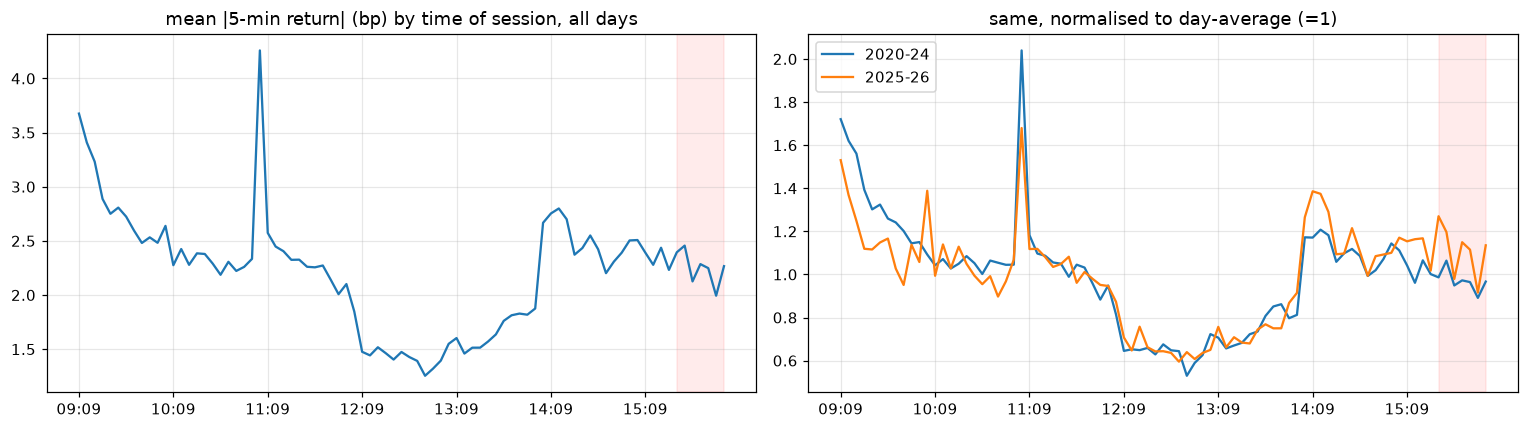

mean |5-min ret| last 30 min: 2.23 bp  vs  10:00-15:30: 2.11 bp  (ratio 1.06)


In [2]:
r5 = (np.log(px.iloc[:, 4::5]).diff(axis=1) * 1e4).iloc[:, 1:]            # 5-min log returns, bp
cols = r5.columns
t_lab = [f"{9 + c // 60:02d}:{c % 60:02d}" for c in cols]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(cols, r5.abs().mean(), lw=1.5)
ax[0].set_title("mean |5-min return| (bp) by time of session, all days")
for lab, m in [("2020-24", D.year <= 2024), ("2025-26", D.year >= 2025)]:
    s = r5[m.reindex(r5.index).values]
    ax[1].plot(cols, s.abs().mean() / s.abs().mean().mean(), lw=1.5, label=lab)
ax[1].set_title("same, normalised to day-average (=1)"); ax[1].legend()
for a in ax:
    a.set_xticks(cols[::12]); a.set_xticklabels(t_lab[::12]); a.axvspan(389, 419, color="red", alpha=0.08)
plt.tight_layout(); plt.show()
last = r5[cols[cols >= 390]].abs().mean().mean(); rest = r5[cols[(cols >= 60) & (cols < 390)]].abs().mean().mean()
print(f"mean |5-min ret| last 30 min: {last:.2f} bp  vs  10:00-15:30: {rest:.2f} bp  (ratio {last / rest:.2f})")

### 2. Event study: average path on big-move days
Days are sorted by the *vol-scaled* open→15:00 move (z-score vs trailing 60-day std, so 2025's high-vol days
don't monopolise the extremes); the conditioning is fixed *before* the window we care about.
Top decile = USD/TWD spiked up (TWD weak), bottom decile = spiked down. If smoothing is real, the extreme
groups should bend back toward zero after 15:00 while the middle group stays flat.

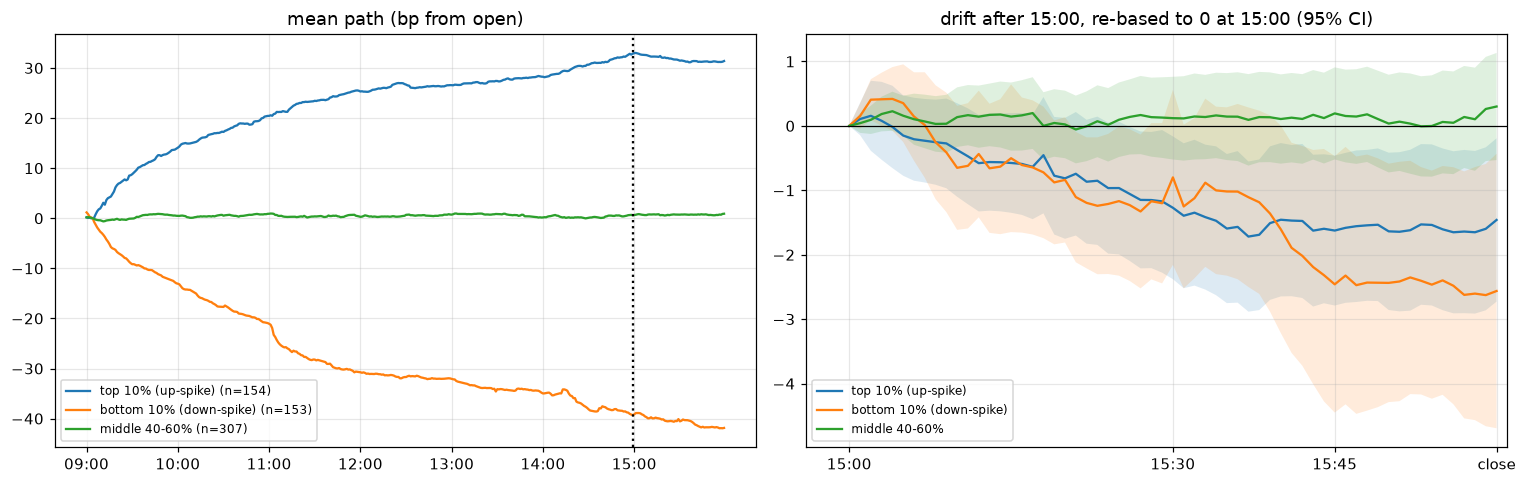

top 10% (up-spike)         mean 15:00->close =  -1.46 bp   t = -2.26
bottom 10% (down-spike)    mean 15:00->close =  -2.56 bp   t = -2.36
middle 40-60%              mean 15:00->close =   0.30 bp   t =  0.71


In [3]:
path = (lp.sub(lp[4], axis=0) * 1e4)                        # bp from open, robust 5-min-median price
q = D["z_15:00"].rank(pct=True)
grp = {"top 10% (up-spike)": q > 0.9, "bottom 10% (down-spike)": q < 0.1, "middle 40-60%": (q > 0.4) & (q < 0.6)}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for lab, m in grp.items():
    p = path[m]
    ax[0].plot(p.columns, p.mean(), label=f"{lab} (n={m.sum()})")
    post = p.sub(p[359], axis=0).iloc[:, 359:]
    mu, se = post.mean(), post.std() / np.sqrt(len(post))
    ax[1].plot(post.columns, mu, label=lab); ax[1].fill_between(post.columns, mu - 1.96 * se, mu + 1.96 * se, alpha=0.15)
ax[0].set_title("mean path (bp from open)"); ax[0].axvline(359, color="k", ls=":")
ax[1].set_title("drift after 15:00, re-based to 0 at 15:00 (95% CI)"); ax[1].axhline(0, color="k", lw=0.8)
for a in ax:
    a.set_xticks(range(0, 420, 60)); a.set_xticklabels([f"{9 + h:02d}:00" for h in range(7)]); a.legend(fontsize=8)
ax[1].set_xlim(355, 420); ax[1].set_xticks([359, 389, 404, 419]); ax[1].set_xticklabels(["15:00", "15:30", "15:45", "close"])
plt.tight_layout(); plt.show()
for lab, m in grp.items():
    post = (path[419] - path[359])[m]
    print(f"{lab:26s} mean 15:00->close = {post.mean():6.2f} bp   t = {post.mean() / post.std() * np.sqrt(len(post)):5.2f}")

### 3. Close-reversal regression
$r_{T\to close} = \alpha + \beta\, r_{open\to T} + \varepsilon$ for T = 15:00, 15:30, 15:45, 15:55.
$\beta<0$ means the close partially undoes the day's move. HC3 robust standard errors.
Then deciles of the open→15:30 move vs the mean last-30-min return, with 95% CIs.

--- linear ---
post_15:00 ~ pre_15:00             beta =  0.0360  (se 0.0445)  t =   0.81  p = 4.18e-01  R2 = 0.010  n = 1566
post_15:30 ~ pre_15:30             beta =  0.0251  (se 0.0372)  t =   0.67  p = 5.01e-01  R2 = 0.009  n = 1566
post_15:45 ~ pre_15:45             beta = -0.0002  (se 0.0056)  t =  -0.03  p = 9.72e-01  R2 = 0.000  n = 1566
post_15:55 ~ pre_15:55             beta =  0.0130  (se 0.0114)  t =   1.14  p = 2.55e-01  R2 = 0.016  n = 1566

--- asymmetric: post = a + b*pre + c*|pre|   (c != 0: drift after big moves in EITHER direction) ---
T=15:00:  b =  0.0184 (t  0.61)    c = -0.0827 (t -1.44)
T=15:30:  b =  0.0103 (t  0.41)    c = -0.0623 (t -1.22)

--- big days only (|z| > 1.5, vol-scaled) ---
post_15:30 ~ pre_15:30 | big       beta =  0.0446  (se 0.0540)  t =   0.83  p = 4.09e-01  R2 = 0.062  n = 201

--- normal days only (|z| < 0.5) ---
post_15:30 ~ pre_15:30 | normal    beta =  0.0394  (se 0.0498)  t =   0.79  p = 4.29e-01  R2 = 0.003  n = 680


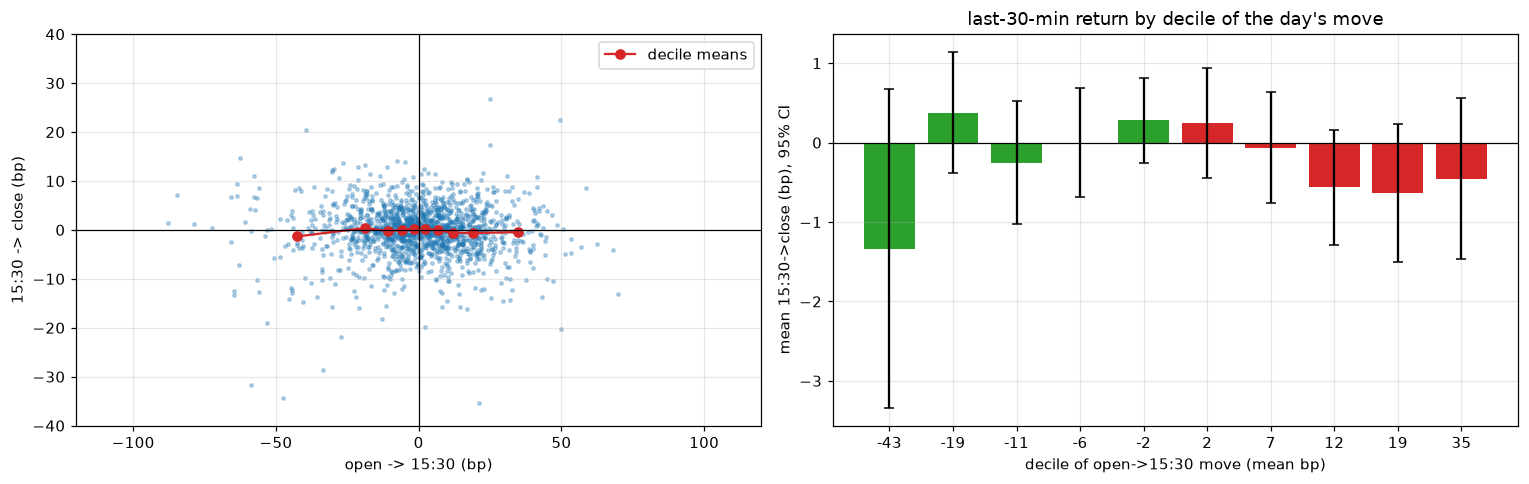

             pre  post     sd    n    ci
pre_15:30                               
0         -42.55 -1.34  12.81  157  2.00
1         -18.81  0.38   4.88  157  0.76
2         -10.64 -0.25   4.90  156  0.77
3          -5.81  0.00   4.39  157  0.69
4          -1.76  0.28   3.44  161  0.53
5           2.24  0.24   4.36  152  0.69
6           6.90 -0.06   4.43  156  0.69
7          11.94 -0.56   4.61  157  0.72
8          18.98 -0.63   5.50  156  0.86
9          34.65 -0.46   6.47  157  1.01


In [4]:
def ols(y, x, label):
    X = sm.add_constant(x); m = sm.OLS(y, X, missing="drop").fit(cov_type="HC3")
    b, se, p = m.params.iloc[1], m.bse.iloc[1], m.pvalues.iloc[1]
    print(f"{label:34s} beta = {b:7.4f}  (se {se:.4f})  t = {b / se:6.2f}  p = {p:.2e}  R2 = {m.rsquared:.3f}  n = {int(m.nobs)}")
    return m

print("--- linear ---")
for k in ["15:00", "15:30", "15:45", "15:55"]:
    ols(D[f"post_{k}"], D[f"pre_{k}"], f"post_{k} ~ pre_{k}")
print("\n--- asymmetric: post = a + b*pre + c*|pre|   (c != 0: drift after big moves in EITHER direction) ---")
for k in ["15:00", "15:30"]:
    X = pd.DataFrame({"pre": D[f"pre_{k}"], "abs_pre": D[f"pre_{k}"].abs()})
    m = sm.OLS(D[f"post_{k}"], sm.add_constant(X), missing="drop").fit(cov_type="HC3")
    print(f"T={k}:  b = {m.params.pre:7.4f} (t {m.tvalues.pre:5.2f})    c = {m.params.abs_pre:7.4f} (t {m.tvalues.abs_pre:5.2f})")
print("\n--- big days only (|z| > 1.5, vol-scaled) ---")
big = D["z_15:30"].abs() > 1.5
ols(D.loc[big, "post_15:30"], D.loc[big, "pre_15:30"], "post_15:30 ~ pre_15:30 | big")
print("\n--- normal days only (|z| < 0.5) ---")
nrm = D["z_15:30"].abs() < 0.5
ols(D.loc[nrm, "post_15:30"], D.loc[nrm, "pre_15:30"], "post_15:30 ~ pre_15:30 | normal")

dec = pd.qcut(D["pre_15:30"], 10, labels=False, duplicates="drop")
tab = D.groupby(dec).agg(pre=("pre_15:30", "mean"), post=("post_15:30", "mean"), sd=("post_15:30", "std"), n=("post_15:30", "size"))
tab["ci"] = 1.96 * tab.sd / np.sqrt(tab.n)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].scatter(D["pre_15:30"], D["post_15:30"], s=5, alpha=0.3)
ax[0].plot(tab.pre, tab.post, "o-", color="C3", label="decile means")
ax[0].set_xlim(-120, 120); ax[0].set_ylim(-40, 40); ax[0].axhline(0, color="k", lw=0.8); ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_xlabel("open -> 15:30 (bp)"); ax[0].set_ylabel("15:30 -> close (bp)"); ax[0].legend()
ax[1].bar(range(len(tab)), tab.post, yerr=tab.ci, capsize=3, color=np.where(tab.pre < 0, "C2", "C3"))
ax[1].set_xticks(range(len(tab))); ax[1].set_xticklabels([f"{v:.0f}" for v in tab.pre]); ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xlabel("decile of open->15:30 move (mean bp)"); ax[1].set_ylabel("mean 15:30->close (bp), 95% CI")
ax[1].set_title("last-30-min return by decile of the day's move")
plt.tight_layout(); plt.show()
print(tab.round(2))

### 4. Placebo: is the reversal *specific to the close*?
Run the identical regression for every 30-minute window in the day: return over [t, t+30] on the
open→t move. Generic intraday mean reversion (bid-ask bounce, momentum traders fading moves) would show
up everywhere; a *policy* effect at the fixing should make the last window stand out.

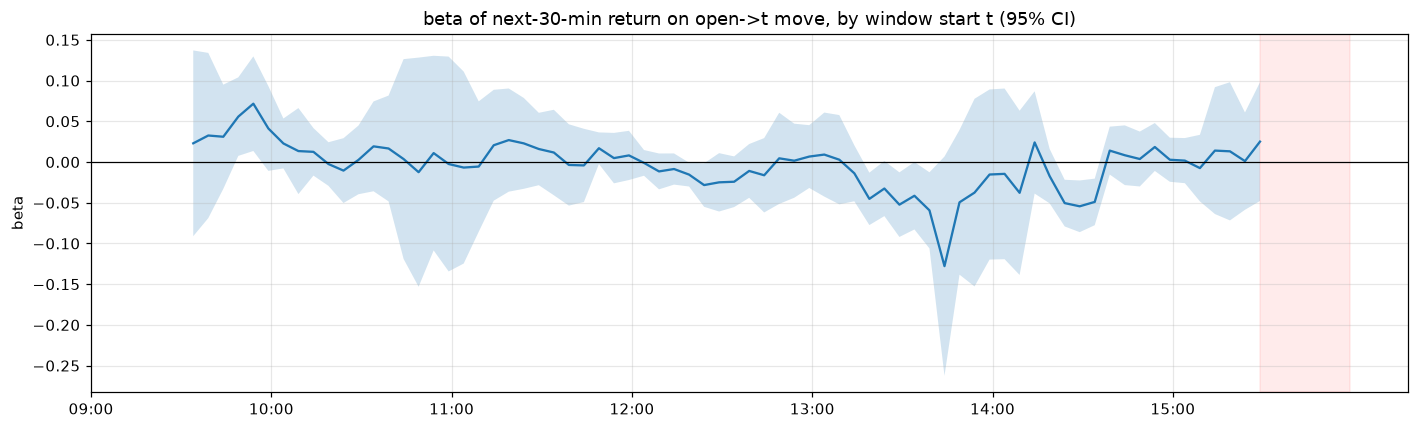

last window (15:30-close): beta = 0.0251 ± 0.0729
other windows:             mean beta = -0.0040, min -0.1279, max 0.0716
z-score of last window vs distribution of other-window betas: 0.98


In [5]:
rows = []
for t in range(34, 390, 5):                                   # window start 09:35 ... 15:30
    y, x = bp(t, t + 30), bp(4, t)
    m = sm.OLS(y, sm.add_constant(x)).fit(cov_type="HC3")
    rows.append(dict(t=t, beta=m.params.iloc[1], se=m.bse.iloc[1]))
P = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(P.t, P.beta, lw=1.5); ax.fill_between(P.t, P.beta - 1.96 * P.se, P.beta + 1.96 * P.se, alpha=0.2)
ax.axhline(0, color="k", lw=0.8); ax.axvspan(389, 419, color="red", alpha=0.08)
ax.set_xticks(range(0, 420, 60)); ax.set_xticklabels([f"{9 + h:02d}:00" for h in range(7)])
ax.set_title("beta of next-30-min return on open->t move, by window start t (95% CI)"); ax.set_ylabel("beta")
plt.tight_layout(); plt.show()
lastb = P.iloc[-1]; others = P.iloc[:-1]
print(f"last window (15:30-close): beta = {lastb.beta:.4f} ± {1.96 * lastb.se:.4f}")
print(f"other windows:             mean beta = {others.beta.mean():.4f}, min {others.beta.min():.4f}, max {others.beta.max():.4f}")
print(f"z-score of last window vs distribution of other-window betas: {(lastb.beta - others.beta.mean()) / others.beta.std():.2f}")

### 5. Extreme days vs normal days
Define the *reversal* on day d as $-\,\mathrm{sign}(r_{open\to15:30}) \times r_{15:30\to close}$ (positive =
the close moved back against the day's direction). Compare big days (|z| > 1.5) with normal days (|z| < 0.5)
using parametric and non-parametric tests, plus a sign test on the fraction of days that reverse.

group                    n  mean rev  median  t-test p  wilcoxon p  %reverse  binom p
big up (z>1.5)          92      0.60    0.34  3.60e-01    2.67e-01     53.3% 6.02e-01
big down (z<-1.5)      109     -1.69    0.32  1.31e-01    9.30e-01     55.2% 3.29e-01
all big (|z|>1.5)      201     -0.65    0.32  3.40e-01    4.72e-01     54.3% 2.54e-01
normal (|z|<0.5)       680     -0.01    0.12  9.68e-01    7.08e-01     52.7% 1.82e-01

big vs normal:  Welch t p = 3.62e-01   Mann-Whitney p = 4.07e-01   2-prop z p = 6.90e-01


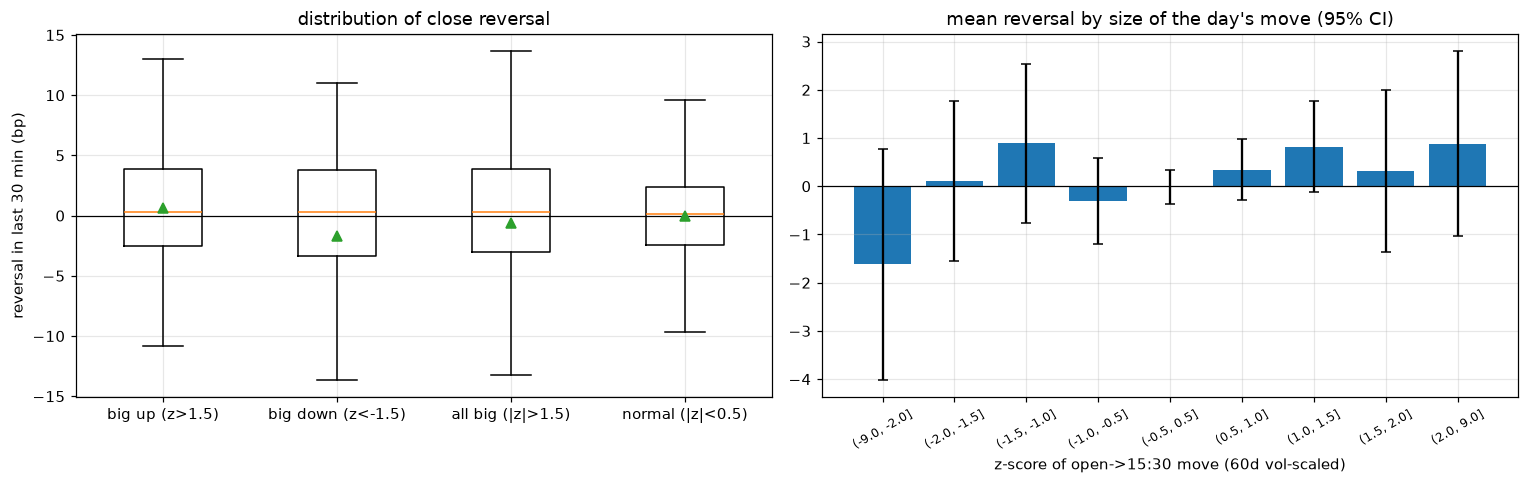

In [6]:
rev = -np.sign(D["pre_15:30"]) * D["post_15:30"]
groups = {"big up (z>1.5)": D["z_15:30"] > 1.5, "big down (z<-1.5)": D["z_15:30"] < -1.5,
          "all big (|z|>1.5)": big, "normal (|z|<0.5)": nrm}
print(f"{'group':20s} {'n':>5s} {'mean rev':>9s} {'median':>7s} {'t-test p':>9s} {'wilcoxon p':>11s} {'%reverse':>9s} {'binom p':>8s}")
for lab, m in groups.items():
    s = rev[m].dropna()
    tp = stats.ttest_1samp(s, 0).pvalue; wp = stats.wilcoxon(s).pvalue
    k = (s > 0).sum(); n = (s != 0).sum(); bpv = stats.binomtest(int(k), int(n), 0.5).pvalue
    print(f"{lab:20s} {len(s):5d} {s.mean():9.2f} {s.median():7.2f} {tp:9.2e} {wp:11.2e} {k / n:9.1%} {bpv:8.2e}")
a, b = rev[big].dropna(), rev[nrm].dropna()
print(f"\nbig vs normal:  Welch t p = {stats.ttest_ind(a, b, equal_var=False).pvalue:.2e}   "
      f"Mann-Whitney p = {stats.mannwhitneyu(a, b).pvalue:.2e}   "
      f"2-prop z p = {sm.stats.proportions_ztest([(a > 0).sum(), (b > 0).sum()], [(a != 0).sum(), (b != 0).sum()])[1]:.2e}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].boxplot([rev[m].dropna() for m in groups.values()], tick_labels=list(groups), showfliers=False, showmeans=True)
ax[0].axhline(0, color="k", lw=0.8); ax[0].set_ylabel("reversal in last 30 min (bp)"); ax[0].set_title("distribution of close reversal")
zb = pd.cut(D["z_15:30"], [-9, -2, -1.5, -1, -0.5, 0.5, 1, 1.5, 2, 9])
tz = rev.groupby(zb).agg(["mean", "std", "size"]); tz["ci"] = 1.96 * tz["std"] / np.sqrt(tz["size"])
ax[1].bar(range(len(tz)), tz["mean"], yerr=tz.ci, capsize=3)
ax[1].set_xticks(range(len(tz))); ax[1].set_xticklabels([str(i) for i in tz.index], rotation=30, fontsize=8)
ax[1].axhline(0, color="k", lw=0.8); ax[1].set_xlabel("z-score of open->15:30 move (60d vol-scaled)")
ax[1].set_title("mean reversal by size of the day's move (95% CI)")
plt.tight_layout(); plt.show()

### 6. Variance ratios by window
Within each 30-min window, $VR = \frac{Var(30\text{-min return})}{6 \cdot Var(5\text{-min return})}$.
A random walk gives VR ≈ 1; VR < 1 means 5-min moves inside the window tend to be undone (mean reversion).
Bootstrap CIs over days.

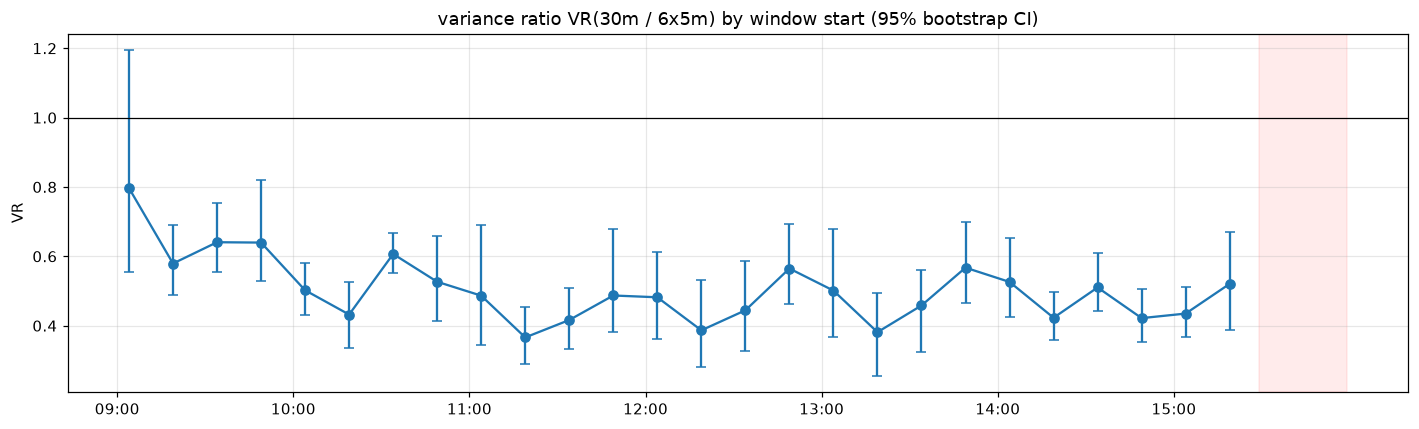

  t    vr    lo    hi
  4 0.797 0.555 1.194
 19 0.579 0.488 0.689
 34 0.641 0.554 0.754
 49 0.640 0.528 0.819
 64 0.502 0.431 0.581
 79 0.432 0.336 0.527
 94 0.607 0.551 0.667
109 0.527 0.414 0.658
124 0.487 0.344 0.690
139 0.366 0.289 0.453
154 0.416 0.332 0.508
169 0.487 0.382 0.679
184 0.482 0.362 0.612
199 0.387 0.280 0.533
214 0.444 0.328 0.586
229 0.565 0.462 0.693
244 0.501 0.367 0.680
259 0.381 0.256 0.495
274 0.458 0.324 0.560
289 0.567 0.466 0.699
304 0.526 0.426 0.653
319 0.423 0.359 0.498
334 0.510 0.441 0.610
349 0.422 0.352 0.505
364 0.435 0.368 0.511
379 0.521 0.387 0.670


In [7]:
rng_ = np.random.default_rng(0)
def vr(t, idx=None):
    sub = px if idx is None else px.iloc[idx]
    r5w = (np.log(sub.iloc[:, t:t + 31:5]).diff(axis=1) * 1e4).iloc[:, 1:]
    r30 = (np.log(sub[t + 30] / sub[t]) * 1e4)
    return r30.var() / (6 * r5w.stack().var())
V = []
for t in range(4, 390, 15):
    boots = [vr(t, rng_.integers(0, len(px), len(px))) for _ in range(200)]
    V.append(dict(t=t, vr=vr(t), lo=np.percentile(boots, 2.5), hi=np.percentile(boots, 97.5)))
V = pd.DataFrame(V)
fig, ax = plt.subplots(figsize=(13, 4))
ax.errorbar(V.t, V.vr, yerr=[V.vr - V.lo, V.hi - V.vr], fmt="o-", capsize=3)
ax.axhline(1, color="k", lw=0.8); ax.axvspan(389, 419, color="red", alpha=0.08)
ax.set_xticks(range(0, 420, 60)); ax.set_xticklabels([f"{9 + h:02d}:00" for h in range(7)])
ax.set_title("variance ratio VR(30m / 6x5m) by window start (95% bootstrap CI)"); ax.set_ylabel("VR")
plt.tight_layout(); plt.show()
print(V.round(3).to_string(index=False))

### 7. Does the offshore market undo the close overnight?
If the CBC pushes the 16:00 close away from where the market clears, the next morning's open (set largely by
the offshore/NDF market overnight) should move back: overnight return should load *negatively* on the last-30-min
move, controlling for the rest of the day. Placebo: the 14:30→15:00 move should not predict the overnight.

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0698      0.517      2.071      0.038       0.057       2.082
post_15:30     0.0227      0.118      0.192      0.848      -0.209       0.254
pre_15:30      0.0161      0.041      0.390      0.696      -0.065       0.097

placebo (14:30-15:00 move):
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.0629      0.514      2.068      0.039       0.056       2.070
r_14:30-15:00     0.0142      0.096      0.148      0.882      -0.173       0.202
pre_14:30         0.0230      0.041      0.568      0.570      -0.056       0.102

big days only:
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

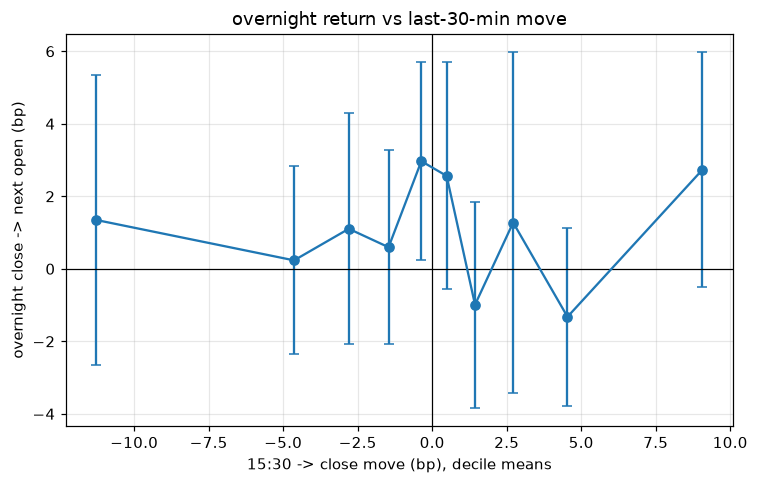

In [8]:
X = pd.DataFrame({"post_15:30": D["post_15:30"], "pre_15:30": D["pre_15:30"]})
m1 = sm.OLS(D.on, sm.add_constant(X), missing="drop").fit(cov_type="HC3")
print(m1.summary().tables[1])
X2 = pd.DataFrame({"r_14:30-15:00": bp(329, 359), "pre_14:30": bp(4, 329)})
m2 = sm.OLS(D.on, sm.add_constant(X2), missing="drop").fit(cov_type="HC3")
print("\nplacebo (14:30-15:00 move):"); print(m2.summary().tables[1])
print("\nbig days only:"); print(sm.OLS(D.on[big], sm.add_constant(X[big]), missing="drop").fit(cov_type="HC3").summary().tables[1])

dq = pd.qcut(D["post_15:30"], 10, labels=False, duplicates="drop")
to = D.groupby(dq).agg(x=("post_15:30", "mean"), y=("on", "mean"), sd=("on", "std"), n=("on", "size")); to["ci"] = 1.96 * to.sd / np.sqrt(to.n)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(to.x, to.y, yerr=to.ci, fmt="o-", capsize=3)
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("15:30 -> close move (bp), decile means"); ax.set_ylabel("overnight close -> next open (bp)")
ax.set_title("overnight return vs last-30-min move")
plt.tight_layout(); plt.show()

### 8. Stability by year
Same close-reversal beta (and the overnight-undo beta) estimated year by year.

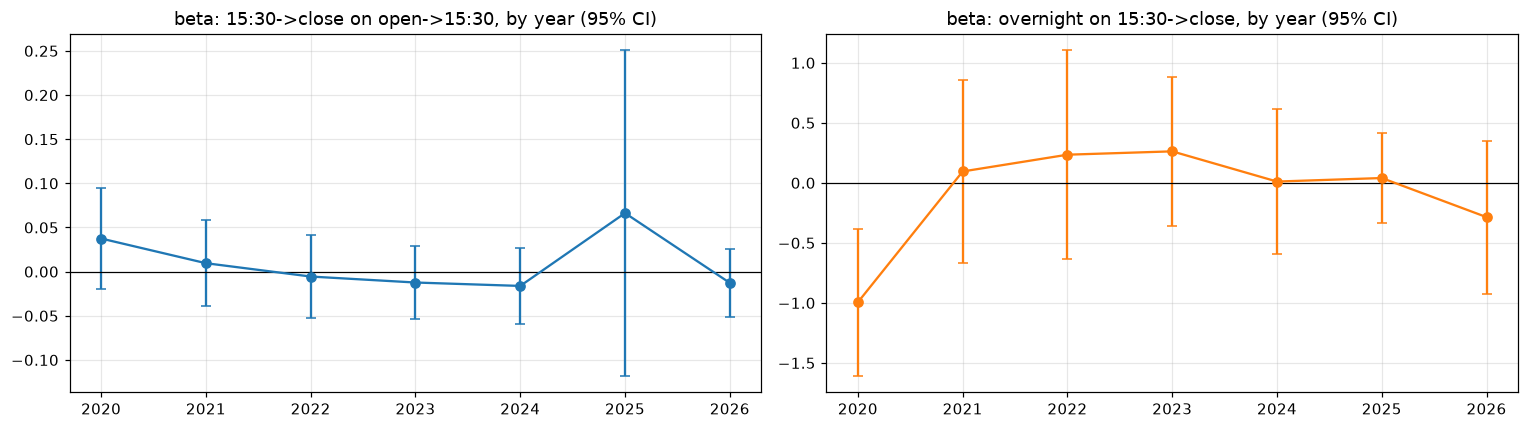

        n  beta_close  se_close  beta_on  se_on  sd_pre
year                                                   
2020  163       0.038     0.029   -0.994  0.312  15.952
2021  252       0.010     0.025    0.095  0.390  16.681
2022  251      -0.006     0.024    0.235  0.443  22.252
2023  256      -0.012     0.021    0.263  0.318  21.310
2024  214      -0.016     0.022    0.011  0.310  19.811
2025  246       0.066     0.094    0.040  0.191  38.547
2026  184      -0.013     0.019   -0.285  0.325  18.205


In [9]:
rows = []
for y, d in D.groupby("year"):
    m = sm.OLS(d["post_15:30"], sm.add_constant(d["pre_15:30"]), missing="drop").fit(cov_type="HC3")
    mo = sm.OLS(d.on, sm.add_constant(d[["post_15:30", "pre_15:30"]]), missing="drop").fit(cov_type="HC3")
    rows.append(dict(year=y, n=len(d), beta_close=m.params.iloc[1], se_close=m.bse.iloc[1],
                     beta_on=mo.params["post_15:30"], se_on=mo.bse["post_15:30"], sd_pre=d["pre_15:30"].std()))
Y = pd.DataFrame(rows).set_index("year")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].errorbar(Y.index, Y.beta_close, yerr=1.96 * Y.se_close, fmt="o-", capsize=3); ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_title("beta: 15:30->close on open->15:30, by year (95% CI)")
ax[1].errorbar(Y.index, Y.beta_on, yerr=1.96 * Y.se_on, fmt="o-", capsize=3, color="C1"); ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("beta: overnight on 15:30->close, by year (95% CI)")
plt.tight_layout(); plt.show()
print(Y.round(3))

### What the data says

**The "CBC smooths the close after an intraday spike" story is not supported by this data.**

| test | what smoothing would look like | what we see |
|---|---|---|
| 1. vol profile | last 30 min unusually active/quiet | last 30 min ≈ rest of day (ratio ≈ 1.06). Real features: 11:00 spike, lunch lull, step up at 14:00 |
| 2. event study | extreme days bend back toward the open after 15:00 | no bend-back. Both extremes drift ≈ −1.5 to −2.5 bp *lower* after 15:00 (t ≈ −2.3), i.e. up-spike days give back a little, down-spike days *continue* |
| 3. reversal regression | β < 0, largest on big days | β ≈ +0.01 to +0.04 at every anchor (15:00/15:30/15:45/15:55), all t < 1; big days β ≈ +0.04 (t 0.8). Decile means all within ±1.5 bp |
| 4. placebo windows | close window stands out | last-window β sits inside the band of the other 71 windows (z ≈ 1) |
| 5. extremes vs normal | higher reversal rate / size on big days | 53–55 % of days "reverse" in every group incl. normal days; all p > 0.1 |
| 6. variance ratios | VR < 1 specifically at the close | VR ≈ 0.4–0.6 in *every* window — that's bid/ask bounce & quote flicker in the feed, not policy |
| 7. overnight undo | offshore market reverses an artificial close (β < 0) | β ≈ +0.02 (p 0.85); big days +0.23 (p 0.27). The close is not undone overnight |
| 8. by year | stable negative β | β_close within ±0.07 every year, all CIs cover 0. Only oddity: 2020 overnight β ≈ −1.0 (t −3), not repeated in any later year |

The one real regularity is small and *direction-independent*: on volatile days USD/TWD drifts a few bp lower
in the last hour whichever way the day went (the |pre| coefficient is ≈ −0.06 to −0.08, t ≈ −1.3, so not even
that is significant). That looks like late-day USD selling (exporters / position squaring), not a stabiliser.

**Caveats / what this does *not* rule out**
- This is a vendor composite feed (Twelve Data), not the Taipei Forex Inc. official closing rate. If the CBC's
  footprint is in the official fixing print rather than in tradable quotes, it won't show up here.
- Intervention that leans against the move *all day* would dampen the whole intraday range rather than reverse
  the close, and cannot be identified from price alone — it needs reserves / interbank-volume data.
- Smoothing at the daily–weekly horizon (a slower crawl than the market wants) is a different hypothesis:
  test with autocorrelation and variance ratios of *daily* changes, and against the CBC's reserve changes.
- Regime: the sample is 2020-04 → 2026-09 and is dominated in the tails by May-2025; results are similar with
  vol-scaled conditioning, but the by-year panel is the honest picture.

## Pitch idea 3 — does equity flow drive the afternoon USD/TWD drift?

**Mechanism:** foreign investors dominate TWSE turnover (TSMC ≈ 30% of the index). When they net-buy Taiwanese
equities they must buy TWD; when they sell, they buy USD. The equity session closes at **13:30**, USD/TWD keeps
trading to 16:00, and the intraday vol profile jumps at ~14:00. Hypothesis: the day's equity flow / index return
(known at 13:30) predicts the **13:30 → 16:00** USD/TWD drift, and the effect is concentrated there rather than
spread evenly across the day.

Data: `data/usdtwd_1m_onshore.csv` + `data/twse_institutional_flows.csv` (TWSE, via FinMind: foreign-investor
buy/sell in TWD) + `data/taiex_daily.csv`. Flow sign convention: **positive = foreign net buying of Taiwan equities**
(→ expected TWD demand → USD/TWD *down*). USD/TWD returns in bp; negative = TWD strengthens.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# ---- USD/TWD 1-min grid (same cleaning as the previous section) ----
raw = pd.read_csv("data/usdtwd_1m_onshore.csv", parse_dates=["datetime"])
raw["date"] = raw.datetime.dt.normalize()
raw["minute"] = (raw.datetime.dt.hour - 9) * 60 + raw.datetime.dt.minute
dmed = raw.groupby("date").close.transform("median")
raw = raw[(np.log(raw.close / dmed) * 1e4).abs() <= 500]
med = raw.groupby("date").close.transform(lambda s: s.rolling(11, center=True, min_periods=3).median())
raw = raw[(np.log(raw.close / med) * 1e4).abs() <= 100]
g = raw.groupby("date"); ok = (g.size() >= 300) & (g.minute.min() <= 5) & (g.minute.max() >= 415)
raw = raw[raw.date.isin(ok[ok].index)]
px = raw.pivot(index="date", columns="minute", values="close").reindex(columns=range(420)).ffill(axis=1).bfill(axis=1)
lp = np.log(px.T.rolling(5, min_periods=1).median().T)          # 5-min-median anchor prices
def bp(a, b): return (lp[b] - lp[a]) * 1e4

# ---- equity side ----
inst = pd.read_csv("data/twse_institutional_flows.csv", parse_dates=["date"])
flow = inst[inst.name == "Foreign_Investor"].set_index("date").pipe(lambda d: (d.buy - d.sell) / 1e9).rename("flow")   # TWD bn
tx = pd.read_csv("data/taiex_daily.csv", parse_dates=["date"]).set_index("date")
tx_ret = (np.log(tx.close / tx.close.shift(1)) * 1e4).rename("tx_cc")            # close-to-close, bp
tx_oc  = (np.log(tx.close / tx.open) * 1e4).rename("tx_oc")                        # open-to-close (09:00-13:30), bp

# ---- day table ----
W = {"overnight": None, "09:00-13:30": (4, 269), "13:30-14:00": (269, 299), "14:00-15:00": (299, 359),
     "15:00-16:00": (359, 419), "13:30-16:00": (269, 419)}
D = pd.DataFrame(index=px.index)
for k, v in W.items():
    if v: D[k] = bp(*v)
D["overnight"] = np.log(px[0] / px[419].shift(1)) * 1e4                # prev close -> today's 09:00
D["next_overnight"] = D["overnight"].shift(-1)
D = D.join(flow).join(tx_ret).join(tx_oc).dropna()
D["flow_z"] = D.flow / D.flow.rolling(60, min_periods=30).std().shift(1)   # vol-scaled flow (lagged std)
D["tx_z"]   = D.tx_oc / D.tx_oc.rolling(60, min_periods=30).std().shift(1)
D["year"] = D.index.year
print(f"{len(D)} matched days, {D.index.min().date()} -> {D.index.max().date()}")
print(D[["flow", "tx_oc", "09:00-13:30", "13:30-16:00", "overnight"]].describe().round(1))
print("\ncorrelations (daily):"); print(D[["flow", "tx_oc", "tx_cc", "overnight", "09:00-13:30", "13:30-16:00", "next_overnight"]].corr().round(2))

1487 matched days, 2020-04-07 -> 2026-09-15
         flow   tx_oc  09:00-13:30  13:30-16:00  overnight
count  1487.0  1487.0       1487.0       1487.0     1487.0
mean     -3.0     0.6         -0.2         -0.8        1.4
std      25.2    96.9         22.7         13.4       20.5
min    -188.3  -583.2       -346.2       -185.8     -183.1
25%     -12.6   -47.8         -9.6         -6.5       -8.4
50%      -1.5     5.9          0.9         -0.3        0.8
75%       9.4    55.3         11.3          5.8       10.3
max     117.8   405.7        185.6         89.3      297.3

correlations (daily):
                flow  tx_oc  tx_cc  overnight  09:00-13:30  13:30-16:00  \
flow            1.00   0.64   0.70      -0.28        -0.25        -0.11   
tx_oc           0.64   1.00   0.90      -0.19        -0.24        -0.05   
tx_cc           0.70   0.90   1.00      -0.29        -0.22        -0.06   
overnight      -0.28  -0.19  -0.29       1.00         0.02        -0.03   
09:00-13:30    -0.25  -0.24

### 1. Which part of the FX day loads on equity flow?
For every window, $r_w = \alpha + \beta_1\, \text{flow}_z + \beta_2\, \text{TAIEX}_z + \varepsilon$ (HC3 SEs).
Both regressors are standardised by trailing 60-day vol so 2025 doesn't dominate. If the mechanism is
"convert after the equity close", the **13:30–16:00** windows should carry a negative flow β *beyond* the morning.

                b_flow  se_flow  p_flow   b_tx  se_tx   p_tx     R2     n
window                                                                   
overnight       -5.973    0.797   0.000  0.256  0.692  0.712  0.096  1457
09:00-13:30     -4.372    0.930   0.000 -2.567  0.911  0.005  0.091  1457
13:30-14:00      0.085    0.165   0.607 -0.340  0.192  0.076  0.003  1457
14:00-15:00     -1.311    0.327   0.000  0.629  0.338  0.063  0.015  1457
15:00-16:00     -0.649    0.290   0.025  0.449  0.274  0.101  0.004  1457
13:30-16:00     -1.875    0.482   0.000  0.738  0.459  0.108  0.015  1457
next_overnight   0.192    0.557   0.730 -0.190  0.641  0.766  0.000  1457


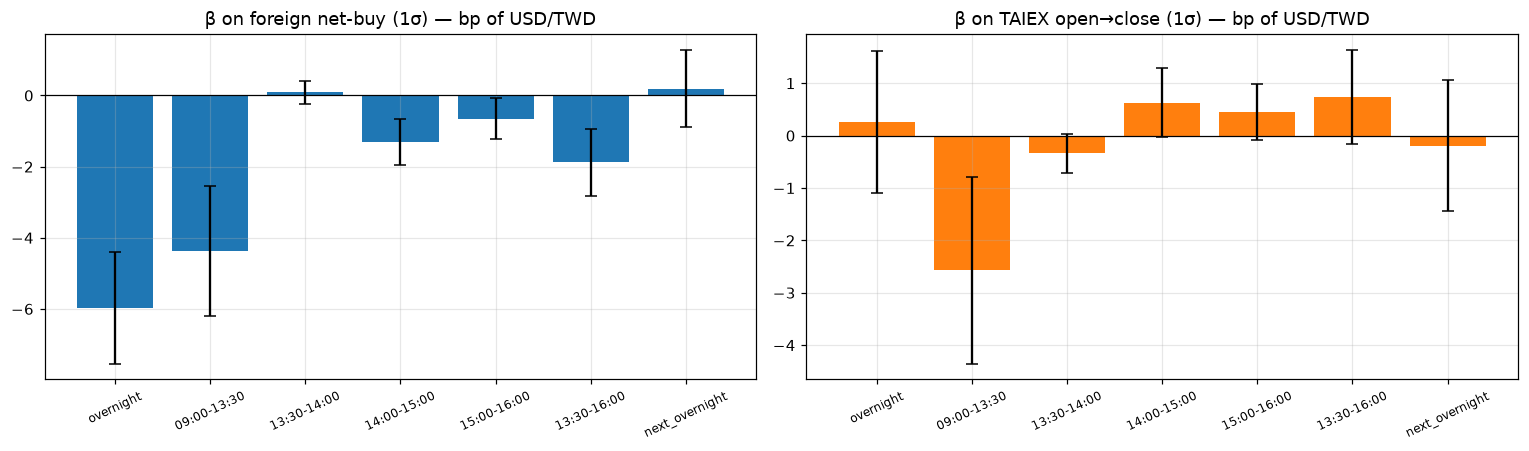

In [2]:
def fit(y, X):
    m = sm.OLS(y, sm.add_constant(X), missing="drop").fit(cov_type="HC3"); return m
rows = []
for w in ["overnight", "09:00-13:30", "13:30-14:00", "14:00-15:00", "15:00-16:00", "13:30-16:00", "next_overnight"]:
    m = fit(D[w], D[["flow_z", "tx_z"]])
    rows.append(dict(window=w, b_flow=m.params.flow_z, se_flow=m.bse.flow_z, p_flow=m.pvalues.flow_z,
                     b_tx=m.params.tx_z, se_tx=m.bse.tx_z, p_tx=m.pvalues.tx_z, R2=m.rsquared, n=int(m.nobs)))
R = pd.DataFrame(rows).set_index("window")
print(R.round(3))
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), sharey=False)
x = np.arange(len(R))
ax[0].bar(x, R.b_flow, yerr=1.96 * R.se_flow, capsize=4, color="C0"); ax[0].set_title("β on foreign net-buy (1σ) — bp of USD/TWD")
ax[1].bar(x, R.b_tx, yerr=1.96 * R.se_tx, capsize=4, color="C1"); ax[1].set_title("β on TAIEX open→close (1σ) — bp of USD/TWD")
for a in ax:
    a.set_xticks(x); a.set_xticklabels(R.index, rotation=25, fontsize=8); a.axhline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()

### 2. Incremental information at 13:30
The morning FX return already reflects the flow (they happen at the same time). What matters for a *trade* is
whether flow / TAIEX predict the afternoon **after controlling for the morning FX move** — and whether the
afternoon is just continuation of the morning trend (which you could trade without any equity data at all).

13:30-16:00 on flow, TAIEX, morning FX, overnight:
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.0335      0.352     -2.940      0.003      -1.723      -0.345
flow_z         -2.5673      0.428     -5.999      0.000      -3.406      -1.728
tx_z            0.5291      0.539      0.982      0.326      -0.527       1.585
09:00-13:30    -0.0865      0.086     -1.008      0.314      -0.255       0.082
overnight      -0.0526      0.021     -2.446      0.014      -0.095      -0.010

R2 with equity vars 0.0390  vs  without 0.0099


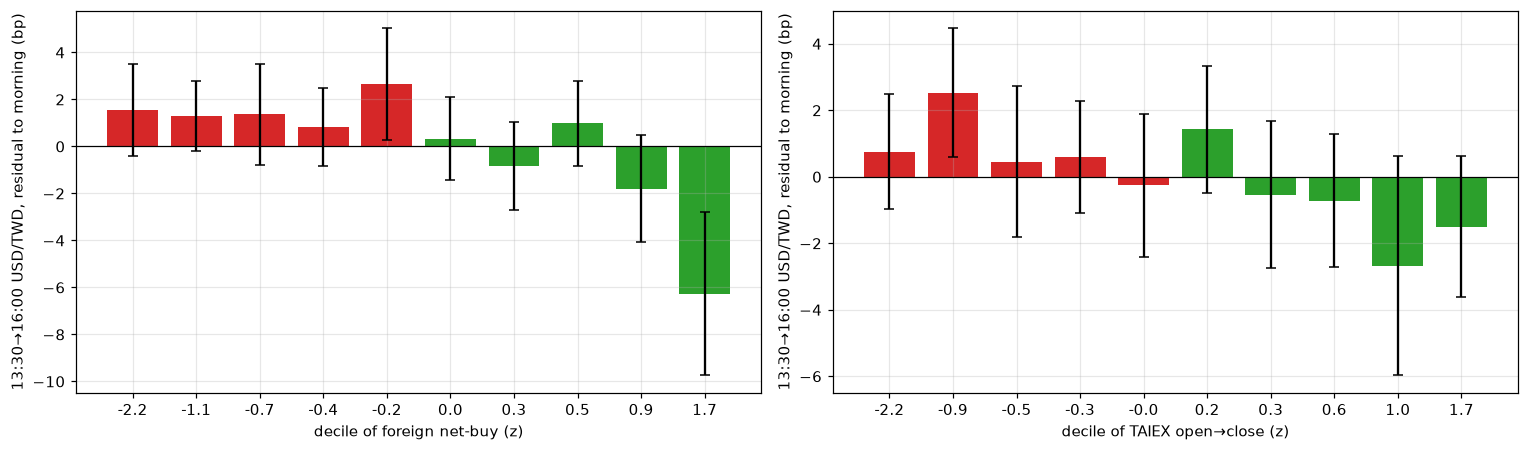

In [3]:
X = D[["flow_z", "tx_z", "09:00-13:30", "overnight"]]
m = fit(D["13:30-16:00"], X); print("13:30-16:00 on flow, TAIEX, morning FX, overnight:"); print(m.summary().tables[1])
m0 = fit(D["13:30-16:00"], D[["09:00-13:30", "overnight"]]); print(f"\nR2 with equity vars {m.rsquared:.4f}  vs  without {m0.rsquared:.4f}")
# partial-out plot: residual afternoon vs flow deciles
resid = D["13:30-16:00"] - m0.predict(sm.add_constant(D[["09:00-13:30", "overnight"]]))
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for a, v, lab in [(ax[0], "flow_z", "foreign net-buy (z)"), (ax[1], "tx_z", "TAIEX open→close (z)")]:
    dec = pd.qcut(D[v], 10, labels=False, duplicates="drop")
    t = pd.DataFrame({"x": D[v], "y": resid}).groupby(dec).agg(x=("x", "mean"), y=("y", "mean"), sd=("y", "std"), n=("y", "size"))
    a.bar(range(len(t)), t.y, yerr=1.96 * t.sd / np.sqrt(t.n), capsize=3, color=np.where(t.x < 0, "C3", "C2"))
    a.set_xticks(range(len(t))); a.set_xticklabels([f"{v:.1f}" for v in t.x]); a.axhline(0, color="k", lw=0.8)
    a.set_xlabel(f"decile of {lab}"); a.set_ylabel("13:30→16:00 USD/TWD, residual to morning (bp)")
plt.tight_layout(); plt.show()

### 3. Timing: where in the afternoon does the drift happen?
Average USD/TWD path from 13:00, re-based to 0 at 13:30, on top-decile inflow days vs top-decile outflow days
(vol-scaled flow). Settlement is T+2, so also check whether *yesterday's* and *two-days-ago* flow matter.

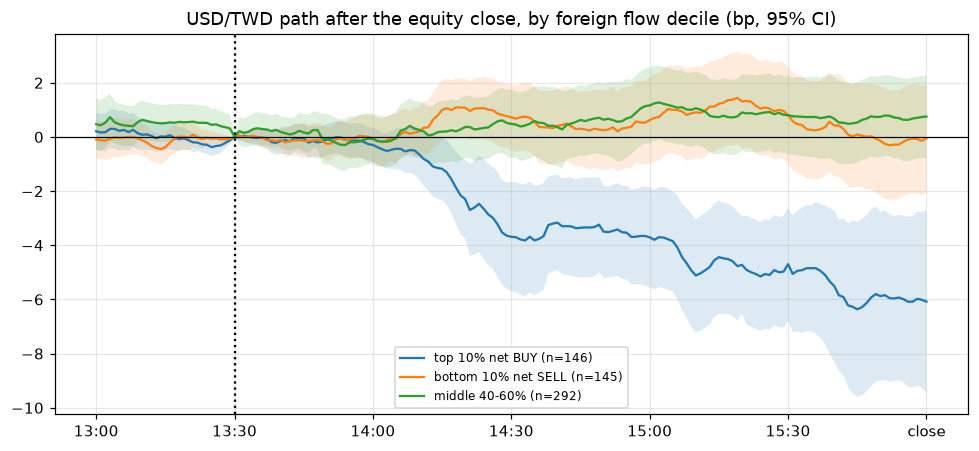

13:30-16:00 on flow lags:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9255      0.343     -2.699      0.007      -1.598      -0.253
flow_t        -2.1949      0.404     -5.427      0.000      -2.987      -1.402
flow_t-1       0.7230      0.380      1.903      0.057      -0.022       1.468
flow_t-2       0.4713      0.341      1.382      0.167      -0.197       1.140
morning       -0.0820      0.084     -0.972      0.331      -0.248       0.083

next overnight on flow lags:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4310      0.556      2.574      0.010       0.341       2.521
flow_t         0.1034      0.501      0.207      0.836      -0.878       1.084
flow_t-1       0.5354      0.513      1.043      0.297      -0.471       1.

In [4]:
path = (lp.sub(lp[269], axis=0) * 1e4).loc[D.index]
q = D.flow_z.rank(pct=True)
grp = {"top 10% net BUY": q > 0.9, "bottom 10% net SELL": q < 0.1, "middle 40-60%": (q > 0.4) & (q < 0.6)}
fig, ax = plt.subplots(figsize=(9, 4.2))
for lab, msk in grp.items():
    p = path[msk].iloc[:, 239:]; mu, se = p.mean(), p.std() / np.sqrt(len(p))
    ax.plot(p.columns, mu, label=f"{lab} (n={msk.sum()})"); ax.fill_between(p.columns, mu - 1.96 * se, mu + 1.96 * se, alpha=0.15)
ax.axvline(269, color="k", ls=":"); ax.axhline(0, color="k", lw=0.8)
ax.set_xticks([239, 269, 299, 329, 359, 389, 419]); ax.set_xticklabels(["13:00", "13:30", "14:00", "14:30", "15:00", "15:30", "close"])
ax.set_title("USD/TWD path after the equity close, by foreign flow decile (bp, 95% CI)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

L = pd.DataFrame({"flow_t": D.flow_z, "flow_t-1": D.flow_z.shift(1), "flow_t-2": D.flow_z.shift(2), "morning": D["09:00-13:30"]})
print("13:30-16:00 on flow lags:"); print(fit(D["13:30-16:00"], L).summary().tables[1])
print("\nnext overnight on flow lags:"); print(fit(D["next_overnight"], L).summary().tables[1])

### 4. Volatility: is the 14:00 vol step a flow effect?
Realised vol (√Σ 5-min r²) in 13:30–16:00 vs |flow|, controlling for morning RV. And the intraday vol profile on
big-|flow| vs small-|flow| days.

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6090      0.083      7.349      0.000       0.447       0.771
log_rv_am      0.6938      0.028     24.844      0.000       0.639       0.748
abs_flow_z     0.0039      0.015      0.250      0.803      -0.026       0.034
abs_tx_z       0.0119      0.021      0.579      0.563      -0.028       0.052


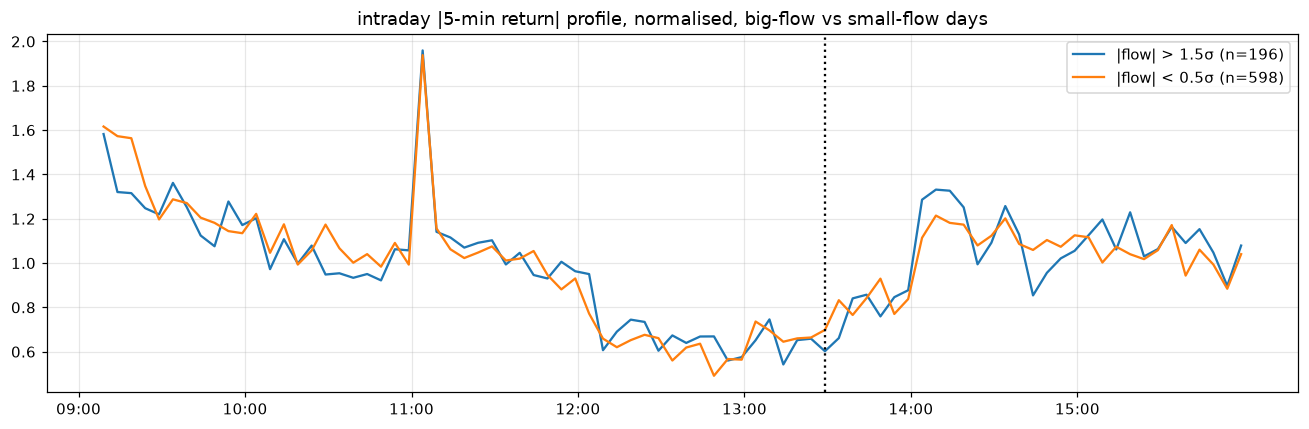

In [5]:
r5 = (np.log(px.iloc[:, 4::5]).diff(axis=1) * 1e4).iloc[:, 1:].loc[D.index]
c = r5.columns
rv_am = np.sqrt((r5[c[(c > 4) & (c <= 269)]] ** 2).sum(axis=1)); rv_pm = np.sqrt((r5[c[c > 269]] ** 2).sum(axis=1))
V = pd.DataFrame({"log_rv_pm": np.log(rv_pm.clip(lower=1)), "log_rv_am": np.log(rv_am.clip(lower=1)), "abs_flow_z": D.flow_z.abs(), "abs_tx_z": D.tx_z.abs()})
print(fit(V.log_rv_pm, V[["log_rv_am", "abs_flow_z", "abs_tx_z"]]).summary().tables[1])
fig, ax = plt.subplots(figsize=(12, 4))
big, small = D.flow_z.abs() > 1.5, D.flow_z.abs() < 0.5
for lab, msk in [("|flow| > 1.5σ", big), ("|flow| < 0.5σ", small)]:
    s = r5[msk].abs().mean(); ax.plot(c, s / s.mean(), label=f"{lab} (n={msk.sum()})")
ax.axvline(269, color="k", ls=":"); ax.set_xticks(range(0, 420, 60)); ax.set_xticklabels([f"{9 + h:02d}:00" for h in range(7)])
ax.set_title("intraday |5-min return| profile, normalised, big-flow vs small-flow days"); ax.legend()
plt.tight_layout(); plt.show()

### 5. Is it tradeable? A 13:30 signal
TAIEX open→close is public at 13:30 (foreign-flow totals are only published ~15:00, so they're not a 13:30
signal — checked separately for 15:00→close). Rule: at 13:30 short USD/TWD if TAIEX is up (expect TWD demand),
long if down; hold to 16:00. Report per-trade bp, hit rate, annualised Sharpe, and the same after a 2 bp
round-trip cost (onshore USD/TWD spread ≈ 1–3 bp).

--- 13:30 -> 16:00, signal = sign(TAIEX open->close) ---
all days, gross                              n=1487  mean=  0.36 bp  hit=48.8%  t= 1.02  Sharpe≈ 0.42
all days, net of 2bp                         n=1487  mean= -1.64 bp  hit=40.8%  t=-4.70  Sharpe≈-1.93
|TAIEX| > 1σ only, net of 2bp                n= 408  mean= -0.38 bp  hit=43.9%  t=-1.29  Sharpe≈-1.02

--- 15:00 -> 16:00, signal = sign(foreign flow) (published ~15:00) ---
all days, gross                              n=1487  mean=  0.24 bp  hit=49.7%  t= 1.14  Sharpe≈ 0.47
|flow| > 1σ only, net of 2bp                 n= 425  mean= -0.39 bp  hit=38.6%  t=-1.53  Sharpe≈-1.18

--- 13:30 -> next 09:00 (hold overnight), signal = sign(TAIEX) ---
all days, net of 2bp                         n=1487  mean= -1.80 bp  hit=45.7%  t=-2.87  Sharpe≈-1.18


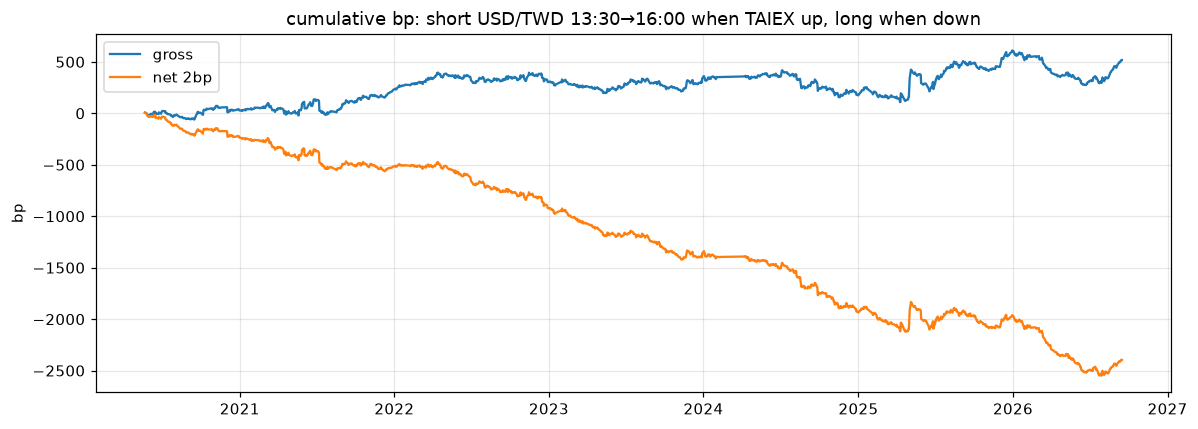

In [6]:
def strat(sig, ret, cost=0.0, label=""):
    pnl = -np.sign(sig) * ret - cost * (sig != 0)
    n = (sig != 0).sum(); mu, sd = pnl.mean(), pnl.std()
    print(f"{label:44s} n={n:4d}  mean={mu:6.2f} bp  hit={((pnl > 0).sum() / n):5.1%}  t={mu / sd * np.sqrt(n):5.2f}  Sharpe≈{mu / sd * np.sqrt(252):5.2f}")
    return pnl
print("--- 13:30 -> 16:00, signal = sign(TAIEX open->close) ---")
p1 = strat(D.tx_z, D["13:30-16:00"], 0, "all days, gross")
strat(D.tx_z, D["13:30-16:00"], 2, "all days, net of 2bp")
strat(D.tx_z.where(D.tx_z.abs() > 1, 0), D["13:30-16:00"], 2, "|TAIEX| > 1σ only, net of 2bp")
print("\n--- 15:00 -> 16:00, signal = sign(foreign flow) (published ~15:00) ---")
strat(D.flow_z, D["15:00-16:00"], 0, "all days, gross")
strat(D.flow_z.where(D.flow_z.abs() > 1, 0), D["15:00-16:00"], 2, "|flow| > 1σ only, net of 2bp")
print("\n--- 13:30 -> next 09:00 (hold overnight), signal = sign(TAIEX) ---")
strat(D.tx_z, D["13:30-16:00"] + D.next_overnight, 2, "all days, net of 2bp")
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(p1.cumsum(), label="gross"); ax.plot((p1 - 2).cumsum(), label="net 2bp")
ax.set_title("cumulative bp: short USD/TWD 13:30→16:00 when TAIEX up, long when down"); ax.legend(); ax.set_ylabel("bp")
plt.tight_layout(); plt.show()

### 6. Stability by year

        n  pm_b_flow  pm_se_flow  pm_b_tx  pm_se_tx  am_b_flow  am_se_flow
year                                                                      
2020  162      -1.51        0.93     0.83      1.09      -2.22        1.56
2021  241      -2.46        0.68    -2.21      1.07      -1.32        1.14
2022  240      -2.29        1.02     0.22      1.03      -3.36        2.03
2023  237      -3.03        0.88     1.95      0.79      -4.35        1.31
2024  205      -2.53        1.13     0.05      0.96      -2.06        1.46
2025  232      -0.85        1.53    -1.61      1.67     -10.57        3.80
2026  170      -3.41        1.16     3.28      1.35      -2.13        1.47


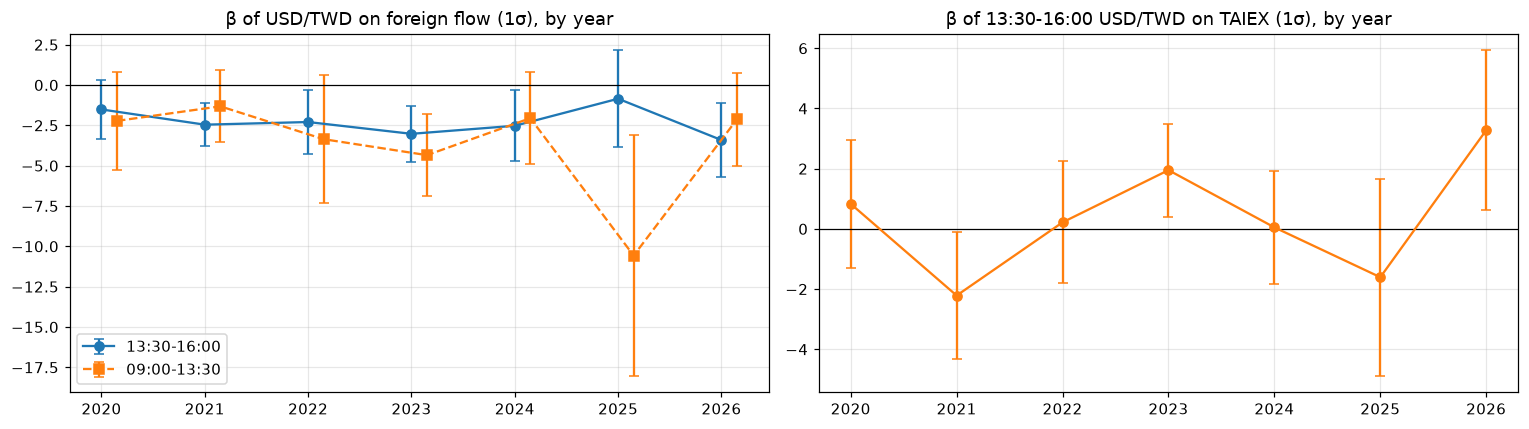

In [7]:
rows = []
for y, d in D.groupby("year"):
    m = fit(d["13:30-16:00"], d[["flow_z", "tx_z", "09:00-13:30"]])
    ma = fit(d["09:00-13:30"], d[["flow_z", "tx_z"]])
    rows.append(dict(year=y, n=len(d), pm_b_flow=m.params.flow_z, pm_se_flow=m.bse.flow_z, pm_b_tx=m.params.tx_z, pm_se_tx=m.bse.tx_z,
                     am_b_flow=ma.params.flow_z, am_se_flow=ma.bse.flow_z))
Y = pd.DataFrame(rows).set_index("year"); print(Y.round(2))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].errorbar(Y.index, Y.pm_b_flow, yerr=1.96 * Y.pm_se_flow, fmt="o-", capsize=3, label="13:30-16:00")
ax[0].errorbar(Y.index + 0.15, Y.am_b_flow, yerr=1.96 * Y.am_se_flow, fmt="s--", capsize=3, label="09:00-13:30")
ax[0].set_title("β of USD/TWD on foreign flow (1σ), by year"); ax[0].legend(); ax[0].axhline(0, color="k", lw=0.8)
ax[1].errorbar(Y.index, Y.pm_b_tx, yerr=1.96 * Y.pm_se_tx, fmt="o-", capsize=3, color="C1"); ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title("β of 13:30-16:00 USD/TWD on TAIEX (1σ), by year")
plt.tight_layout(); plt.show()

### 7. Asymmetry: inflows vs outflows
The event study above looks one-sided. Split the flow into its positive and negative parts:
$r_{13:30-16:00} = \alpha + \beta^+ \max(f,0) + \beta^- \min(f,0) + \gamma\, r_{morning} + \varepsilon$.

14:00-15:00:  beta+ (inflow) =  -3.17 (t -6.96)   beta- (outflow) =  -0.04 (t -0.10)   Wald beta+ = beta-: p = 0.000
15:00-16:00:  beta+ (inflow) =  -0.56 (t -1.28)   beta- (outflow) =   0.18 (t  0.51)   Wald beta+ = beta-: p = 0.244
13:30-16:00:  beta+ (inflow) =  -4.40 (t -6.70)   beta- (outflow) =  -0.22 (t -0.37)   Wald beta+ = beta-: p = 0.000


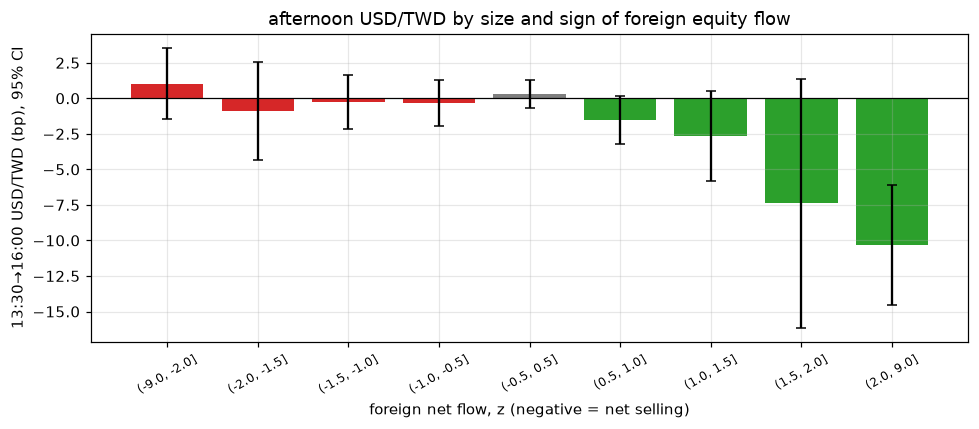

In [8]:
A = pd.DataFrame({"inflow": D.flow_z.clip(lower=0), "outflow": D.flow_z.clip(upper=0), "morning": D["09:00-13:30"]})
for w in ["14:00-15:00", "15:00-16:00", "13:30-16:00"]:
    m = fit(D[w], A)
    print(f"{w}:  beta+ (inflow) = {m.params.inflow:6.2f} (t {m.tvalues.inflow:5.2f})   beta- (outflow) = {m.params.outflow:6.2f} (t {m.tvalues.outflow:5.2f})   "
          f"Wald beta+ = beta-: p = {m.wald_test('inflow = outflow', scalar=True).pvalue:.3f}")
zb = pd.cut(D.flow_z, [-9, -2, -1.5, -1, -0.5, 0.5, 1, 1.5, 2, 9])
tz = D["13:30-16:00"].groupby(zb).agg(["mean", "std", "size"]); tz["ci"] = 1.96 * tz["std"] / np.sqrt(tz["size"])
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(tz)), tz["mean"], yerr=tz.ci, capsize=3, color=["C3"] * 4 + ["C7"] + ["C2"] * 4)
ax.set_xticks(range(len(tz))); ax.set_xticklabels([str(i) for i in tz.index], rotation=30, fontsize=8); ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("foreign net flow, z (negative = net selling)"); ax.set_ylabel("13:30→16:00 USD/TWD (bp), 95% CI")
ax.set_title("afternoon USD/TWD by size and sign of foreign equity flow")
plt.tight_layout(); plt.show()

### Findings

**The mechanism is real; the trade isn't (with public data).**

| | result |
|---|---|
| Flow → afternoon FX | 1σ of foreign net-buying ⇒ USD/TWD **−1.9 bp** in 13:30–16:00 (t ≈ −3.9); **−2.6 bp** (t ≈ −6.0) after controlling for the morning FX move and overnight. R² of the afternoon quadruples (0.010 → 0.039) when flow is added. |
| Where in the afternoon | Nothing in 13:30–14:00; **most of it in 14:00–15:00** (β −1.3, p < 0.001); the rest in 15:00–16:00 (β −0.65, p 0.03). Top-decile inflow days drift ≈ 5–7 bp lower after 13:30; top-decile outflow days drift higher. |
| TAIEX return | Predicts the *morning* (contemporaneous, β −2.6) but **not the afternoon** once flow is in (β +0.5, p 0.33). It's the flow, not the index — consistent with FX conversion rather than generic risk sentiment. |
| Lags | Yesterday's flow has a small *positive* (partial give-back) β ≈ +0.7 (p 0.06); no T+2 settlement effect; no spill into the next overnight. The conversion looks same-day. |
| Asymmetry | **One-sided.** Net-buy days: USD/TWD falls (β⁺ = −4.4 bp/σ over 13:30–16:00, t −6.7; −3.2 in 14:00–15:00 alone); net-sell days: flat (β⁻ = −0.2, t −0.4; Wald p < 0.001). Inflows get converted the same afternoon; outflows don't push USD/TWD up — consistent with a market where USD supply (exporters, and possibly the CBC leaning against TWD weakness) absorbs outflow conversion. |
| Vol | Afternoon realised vol does **not** depend on |flow| (p 0.8). The 14:00 vol step is *not* a flow effect — likely London / global desks coming in. |
| Stability | Afternoon flow β is negative in all 7 years (−0.9 to −3.4 bp/σ); weakest in 2025 when the morning β exploded (−10.6) — the May-2025 episode moved everything at once. |
| Tradeable? | Signal available at 13:30 (sign of TAIEX): +0.36 bp/trade gross, **−1.6 bp net** of a 2 bp round trip. Signal available at ~15:00 (published flow): +0.24 bp gross, negative net. Holding overnight doesn't help. |

**So what's the pitch?** The economically meaningful signal — foreign equity flow — is only *published* after most
of the FX drift has already happened (14:00–15:00). The edge is in **nowcasting the flow at 13:30** from things
that are observable in real time: foreign-broker-tagged volume in TSMC/large caps, TWSE intraday odd-lot / block
data, TSM ADR premium at the Taipei open, or the morning USD/TWD move itself. Because the effect is one-sided, the
nowcast only has to identify *large inflow* days: those drift ≈ 6 bp lower after 14:00, which clears a 2 bp spread even
if the nowcast is only moderately accurate.
That is the study to run next.

**Caveats.** Vendor FX composite, not TFI prints; 2 bp is a rough onshore cost (real fill depends on size and
counterparty); FinMind aggregates TWSE only (no TPEx), fine for foreign flow which is TWSE-dominated.

## Pitch idea 1 — the 11:00 TAIFX1 fix

**What happens at 11:00.** USD/TWD non-deliverable forwards cash-settle against the *Taipei Forex Inc.* spot rate at
**11:00 a.m. Taipei**, published on Reuters page **TAIFX1** (ISDA/EMTA "TWD TAIFX1 (TWD03)"; also the final settlement
price of TAIFEX's cleared TWD NDF). The first trade through TFI at 11:00 sets the print. This is the TWD analogue of
the WM/Reuters 4pm London fix, where the literature (Evans 2018; Ito & Yamada 2017) finds: (i) a burst of volume and
volatility at the fix, (ii) drift *into* the fix as hedgers execute fix-priced orders, (iii) partial *reversal* after.

**Hypotheses.** H1: volatility and range spike in the 11:00–11:01 bars (fix-print activity). H2: the pre-fix move
(10:30→11:00) is partly transitory — the 11:00→11:30 return loads negatively on it, more than the same 30-min
regression does at any other time of day. H3: the effect is larger on days with more NDF settlement — month-end
and IMM (3rd-Wednesday) dates. H4: a fade-the-fix rule is (or isn't) worth trading after cost.

Minute convention: bar `11:00` covers 11:00:00–11:00:59, so the *pre-fix price* is the 10:59 close (= 11:00:00) and
the *post-print price* is the 11:01 close. Raw 1-min closes are used here (the 5-min medians of earlier sections would
smear a 2-minute event); the >5 % / >100 bp bad-tick filters are still applied.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

raw = pd.read_csv("data/usdtwd_1m_onshore.csv", parse_dates=["datetime"])
raw["date"] = raw.datetime.dt.normalize()
raw["minute"] = (raw.datetime.dt.hour - 9) * 60 + raw.datetime.dt.minute
dmed = raw.groupby("date").close.transform("median")
raw = raw[(np.log(raw.close / dmed) * 1e4).abs() <= 500]
med = raw.groupby("date").close.transform(lambda s: s.rolling(11, center=True, min_periods=3).median())
raw = raw[(np.log(raw.close / med) * 1e4).abs() <= 100]
g = raw.groupby("date"); ok = (g.size() >= 300) & (g.minute.min() <= 5) & (g.minute.max() >= 415)
raw = raw[raw.date.isin(ok[ok].index)]
px = raw.pivot(index="date", columns="minute", values="close").reindex(columns=range(420)).ffill(axis=1).bfill(axis=1)
hl = raw.assign(r=np.log(raw.high / raw.low) * 1e4).pivot(index="date", columns="minute", values="r").reindex(columns=range(420))
lpx = np.log(px); r1 = lpx.diff(axis=1) * 1e4
def bp(a, b): return (lpx[b] - lpx[a]) * 1e4
def lab(m): return f"{9 + m // 60:02d}:{m % 60:02d}"
FIX, PRINT = 119, 121                      # 10:59 close (=11:00:00) and 11:01 close
years = px.index.year
print(f"{len(px)} sessions")

1566 sessions


### 1. H1 — the fix is a volatility event (zoom 10:30–11:30)

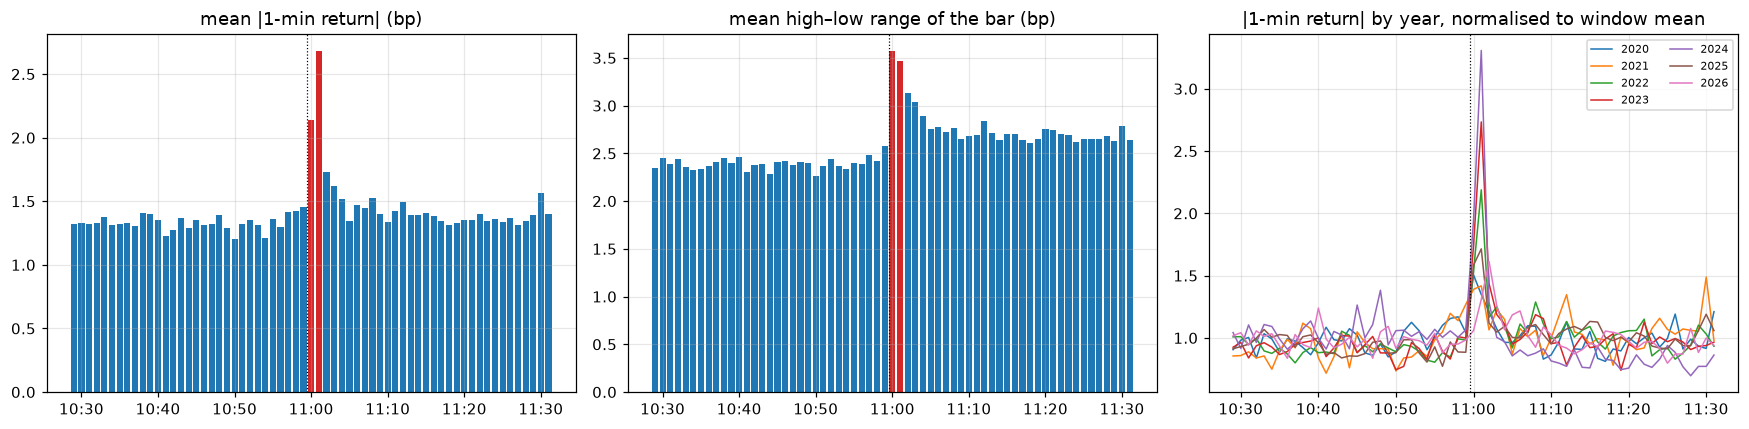

|move| over 11:00–11:01 bars: mean 4.82 bp  vs  2 neighbouring minutes 2.75 bp  (ratio 1.76);  Wilcoxon p = 5.8e-71
mean signed 11:00–11:01 return: -0.43 bp (t -2.90);  next 29 min: -0.45 bp (t -2.10)
by year, mean signed fix move (bp): {2020: -0.45, 2021: 0.04, 2022: -0.59, 2023: -0.52, 2024: -0.6, 2025: -0.77, 2026: -0.06}


In [2]:
z = range(89, 152)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(z, r1[list(z)].abs().mean(), color=["C3" if m in (120, 121) else "C0" for m in z]); ax[0].set_title("mean |1-min return| (bp)")
ax[1].bar(z, hl[list(z)].mean(), color=["C3" if m in (120, 121) else "C0" for m in z]); ax[1].set_title("mean high–low range of the bar (bp)")
for y in sorted(set(years)):
    s = r1.loc[years == y, list(z)].abs().mean(); ax[2].plot(z, s / s.mean(), lw=1, label=str(y))
ax[2].set_title("|1-min return| by year, normalised to window mean"); ax[2].legend(fontsize=7, ncol=2)
for a in ax:
    a.set_xticks(range(90, 152, 10)); a.set_xticklabels([lab(m) for m in range(90, 152, 10)]); a.axvline(119.5, color="k", ls=":", lw=0.8)
plt.tight_layout(); plt.show()
fix_abs = r1[[120, 121]].abs().sum(axis=1); nbr_abs = r1[list(range(105, 118)) + list(range(124, 137))].abs().mean(axis=1) * 2
print(f"|move| over 11:00–11:01 bars: mean {fix_abs.mean():.2f} bp  vs  2 neighbouring minutes {nbr_abs.mean():.2f} bp  (ratio {fix_abs.mean() / nbr_abs.mean():.2f});  "
      f"Wilcoxon p = {stats.wilcoxon(fix_abs - nbr_abs).pvalue:.1e}")
sg = r1[[120, 121]].sum(axis=1); after = bp(PRINT, PRINT + 29)
print(f"mean signed 11:00–11:01 return: {sg.mean():+.2f} bp (t {sg.mean() / sg.std() * np.sqrt(len(sg)):.2f});  next 29 min: {after.mean():+.2f} bp (t {after.mean() / after.std() * np.sqrt(len(after)):.2f})")
print("by year, mean signed fix move (bp):", {int(y): round(v, 2) for y, v in sg.groupby(years).mean().items()})

### 2. H2 — pre-fix drift, post-fix reversal (the WM/R test, with a placebo for every other time of day)
For each time $t$: $r_{t\to t+30} = \alpha + \beta\, r_{t-30\to t} + \varepsilon$ (HC3). Generic 30-min mean reversion
(bid–ask bounce) would give $\beta<0$ everywhere; a *fix* effect makes $t = 11{:}00$ stand out. Also shown: the same
with the 2-minute *print* (10:59→11:01) as the regressor, and the average path around the fix by pre-fix decile.

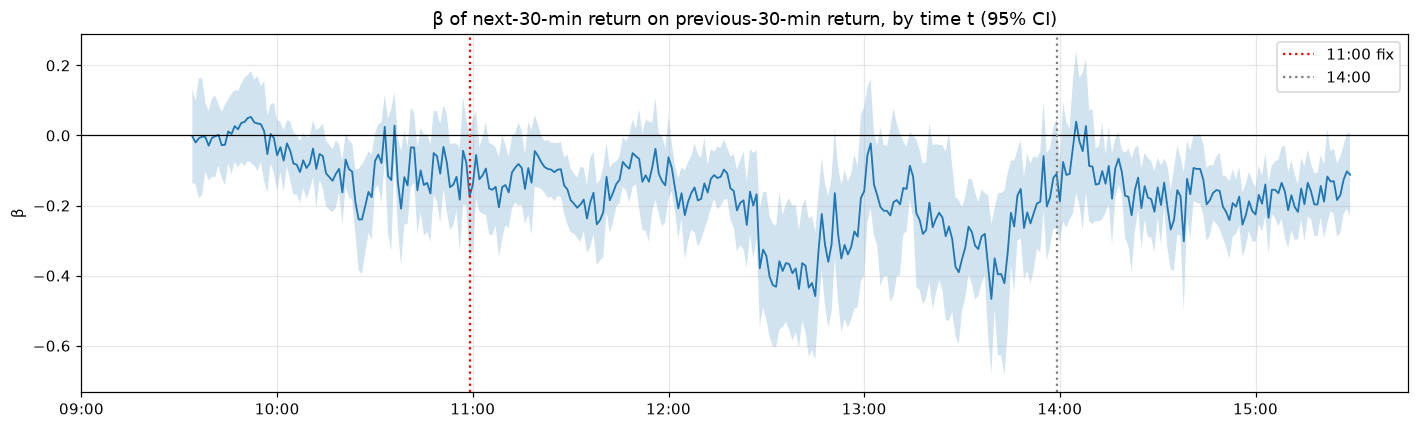

β at 11:00 = -0.174 ± 0.176;  other times: mean -0.163, sd 0.105, 5th pct -0.372  → z = -0.11
rank of the 11:00 β among all 356 start times (1 = most negative): 143


2-min 'print' reversal: β at 11:00 = -0.217 ± 0.203;  other times mean -0.397, sd 0.173  → z = 1.04;  rank 307 of 354
post (11:00→11:30) on pre (10:30→11:00)          β =  -0.174  t =  -1.94  R² = 0.017
post-print (11:01→11:30) on print (10:59→11:01)  β =  -0.217  t =  -2.10  R² = 0.022
print (10:59→11:01) on pre (10:30→11:00)         β =  -0.192  t =  -2.42  R² = 0.049


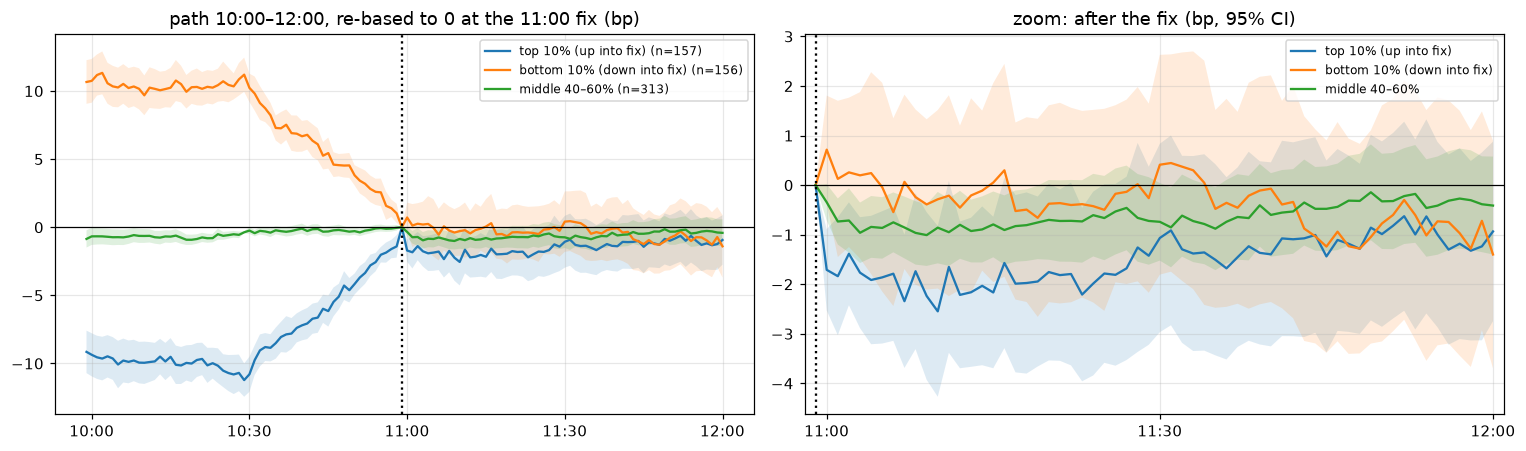

top 10% (up into fix)        pre =   11.2 bp   post (11:00→11:30) = -1.42 bp  t = -1.55   reversal share = 13%
bottom 10% (down into fix)   pre =  -11.2 bp   post (11:00→11:30) = -0.26 bp  t = -0.27   reversal share = -2%
middle 40–60%                pre =    0.4 bp   post (11:00→11:30) = -0.72 bp  t = -1.60   reversal share = 195%


In [3]:
rows = []
for t in range(34, 390):
    m = sm.OLS(bp(t, t + 30), sm.add_constant(bp(t - 30, t)), missing="drop").fit(cov_type="HC3")
    rows.append(dict(t=t, beta=m.params.iloc[1], se=m.bse.iloc[1]))
P = pd.DataFrame(rows).set_index("t")
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(P.index, P.beta, lw=1.2); ax.fill_between(P.index, P.beta - 1.96 * P.se, P.beta + 1.96 * P.se, alpha=0.2)
ax.axhline(0, color="k", lw=0.8); ax.axvline(FIX, color="r", ls=":", label="11:00 fix"); ax.axvline(299, color="gray", ls=":", label="14:00")
ax.set_xticks(range(0, 420, 60)); ax.set_xticklabels([f"{9 + h:02d}:00" for h in range(7)]); ax.legend()
ax.set_title("β of next-30-min return on previous-30-min return, by time t (95% CI)"); ax.set_ylabel("β")
plt.tight_layout(); plt.show()
bf, ob = P.loc[FIX], P.drop(index=range(FIX - 5, FIX + 6))
print(f"β at 11:00 = {bf.beta:.3f} ± {1.96 * bf.se:.3f};  other times: mean {ob.beta.mean():.3f}, sd {ob.beta.std():.3f}, 5th pct {ob.beta.quantile(.05):.3f}  → z = {(bf.beta - ob.beta.mean()) / ob.beta.std():.2f}")
print(f"rank of the 11:00 β among all {len(P)} start times (1 = most negative): {int((P.beta <= bf.beta).sum())}")

rows = []
for t in range(34, 388):
    m = sm.OLS(bp(t + 2, t + 31), sm.add_constant(bp(t, t + 2)), missing="drop").fit(cov_type="HC3")
    rows.append(dict(t=t, beta=m.params.iloc[1], se=m.bse.iloc[1]))
P2 = pd.DataFrame(rows).set_index("t"); b2, o2 = P2.loc[FIX], P2.drop(index=range(FIX - 5, FIX + 6))
print(f"2-min 'print' reversal: β at 11:00 = {b2.beta:.3f} ± {1.96 * b2.se:.3f};  other times mean {o2.beta.mean():.3f}, sd {o2.beta.std():.3f}  → z = {(b2.beta - o2.beta.mean()) / o2.beta.std():.2f};  rank {int((P2.beta <= b2.beta).sum())} of {len(P2)}")

pre, post, jump, post2 = bp(FIX - 30, FIX), bp(FIX, FIX + 30), bp(FIX, PRINT), bp(PRINT, PRINT + 29)
for x_, y_, l in [(pre, post, "post (11:00→11:30) on pre (10:30→11:00)"), (jump, post2, "post-print (11:01→11:30) on print (10:59→11:01)"),
                  (pre, jump, "print (10:59→11:01) on pre (10:30→11:00)")]:
    m = sm.OLS(y_, sm.add_constant(x_), missing="drop").fit(cov_type="HC3")
    print(f"{l:48s} β = {m.params.iloc[1]:7.3f}  t = {m.tvalues.iloc[1]:6.2f}  R² = {m.rsquared:.3f}")

path = lpx.sub(lpx[FIX], axis=0) * 1e4
q = pre.rank(pct=True); grp = {"top 10% (up into fix)": q > .9, "bottom 10% (down into fix)": q < .1, "middle 40–60%": (q > .4) & (q < .6)}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for l, msk in grp.items():
    p = path[msk].loc[:, 59:180]; mu, se = p.mean(), p.std() / np.sqrt(len(p))
    ax[0].plot(p.columns, mu, label=f"{l} (n={msk.sum()})"); ax[0].fill_between(p.columns, mu - 1.96 * se, mu + 1.96 * se, alpha=.15)
    pp = path[msk].loc[:, 119:180]; mu, se = pp.mean(), pp.std() / np.sqrt(len(pp))
    ax[1].plot(pp.columns, mu, label=l); ax[1].fill_between(pp.columns, mu - 1.96 * se, mu + 1.96 * se, alpha=.15)
for a, ttl in zip(ax, ["path 10:00–12:00, re-based to 0 at the 11:00 fix (bp)", "zoom: after the fix (bp, 95% CI)"]):
    a.axvline(FIX, color="k", ls=":"); a.axhline(0, color="k", lw=.8); a.set_title(ttl); a.legend(fontsize=8)
    a.set_xticks(range(60, 181, 30)); a.set_xticklabels([lab(m) for m in range(60, 181, 30)])
ax[1].set_xlim(118, 181)
plt.tight_layout(); plt.show()
for l, msk in grp.items():
    s = post[msk]; print(f"{l:28s} pre = {pre[msk].mean():6.1f} bp   post (11:00→11:30) = {s.mean():5.2f} bp  t = {s.mean() / s.std() * np.sqrt(len(s)):5.2f}   reversal share = {-s.mean() / pre[msk].mean():.0%}")

### 3. H3 — is it bigger when more NDFs settle? (month-end, IMM dates, day-of-week)
NDF maturities cluster on the last business day of the month and on IMM dates (3rd Wednesday). If the fix effect is
hedging flow, both the |print| and the reversal should be larger on those days.

                n  abs_print  abs_pre  beta_rev     se  mw_p_vs_other
bucket                                                               
other        1249      4.753    4.337    -0.181  0.107            NaN
month_end     245      4.611    4.083    -0.125  0.095          0.188
month_start   148      5.124    4.871    -0.205  0.332          0.749
imm            73      6.622    3.985    -0.262  0.316          0.015
friday        308      5.042    4.533    -0.267  0.155          0.373


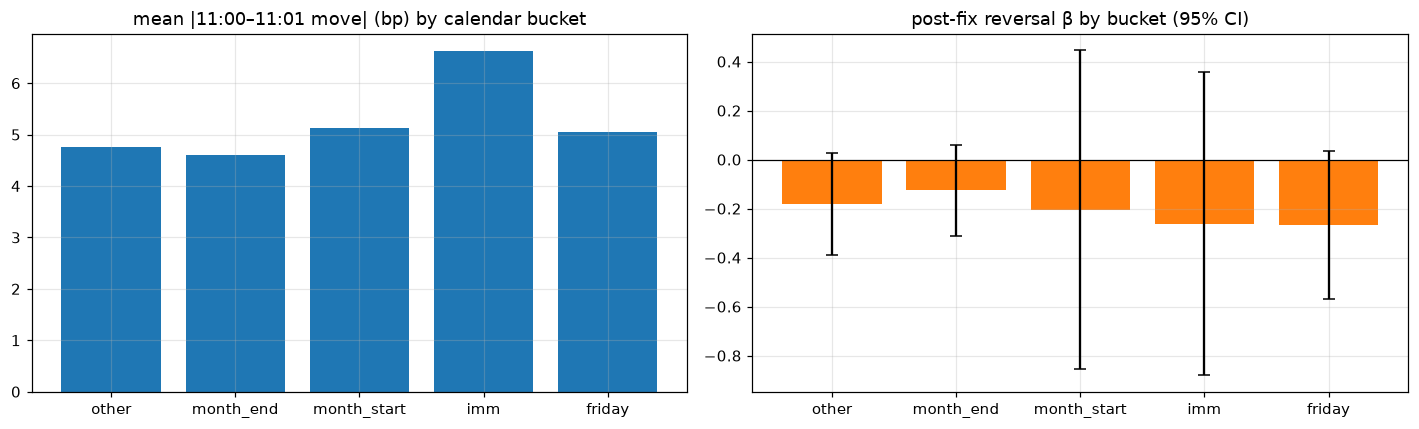

In [4]:
idx = px.index
cal = pd.DataFrame(index=idx)
mon = idx.to_period("M"); last_bd = pd.Series(idx, index=idx).groupby(mon).transform("max")
cal["month_end"] = (idx >= (last_bd - pd.Timedelta(days=3)).values) & (idx <= last_bd.values)          # last ~2 business days
cal["month_start"] = idx.day <= 3
cal["imm"] = (idx.weekday == 2) & (idx.day >= 15) & (idx.day <= 21)
cal["friday"] = idx.weekday == 4
cal["other"] = ~(cal.month_end | cal.imm)
T = pd.DataFrame({"|print| bp": fix_abs, "pre": pre, "post": post})
rows = []
for c in ["other", "month_end", "month_start", "imm", "friday"]:
    m = cal[c]; mm = sm.OLS(post[m], sm.add_constant(pre[m]), missing="drop").fit(cov_type="HC3")
    rows.append(dict(bucket=c, n=int(m.sum()), abs_print=fix_abs[m].mean(), abs_pre=pre[m].abs().mean(), beta_rev=mm.params.iloc[1], se=mm.bse.iloc[1],
                     mw_p_vs_other=stats.mannwhitneyu(fix_abs[m], fix_abs[cal.other]).pvalue if c != "other" else np.nan))
C = pd.DataFrame(rows).set_index("bucket"); print(C.round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(C.index, C.abs_print, color="C0"); ax[0].set_title("mean |11:00–11:01 move| (bp) by calendar bucket")
ax[1].bar(C.index, C.beta_rev, yerr=1.96 * C.se, capsize=4, color="C1"); ax[1].axhline(0, color="k", lw=.8); ax[1].set_title("post-fix reversal β by bucket (95% CI)")
plt.tight_layout(); plt.show()

### 4. H4 — fade the fix: is it tradeable?
Rule: at 11:01 (after the print), if the 10:30→11:01 move is > +τ bp, short USD/TWD; if < −τ, long; exit 11:30.
Reported gross and net of a 2 bp round-trip (onshore spread ≈ 1–3 bp). Also the version that exits at 12:00 and
the one that uses only the 2-minute print as the signal.

--- signal = 10:30→11:01 move, hold to 11:30 ---
gross                                  τ=   0  n= 1548  mean=  0.37 bp  hit=52.1%  t= 1.71  Sharpe≈ 0.69
net 2bp                                τ=   0  n= 1548  mean= -1.63 bp  hit=37.1%  t=-7.55  Sharpe≈-3.03
gross                                  τ=   5  n=  618  mean=  0.46 bp  hit=55.7%  t= 1.22  Sharpe≈ 0.49
net 2bp                                τ=   5  n=  618  mean= -1.54 bp  hit=41.3%  t=-4.09  Sharpe≈-1.64
gross                                  τ=  10  n=  215  mean=  1.48 bp  hit=60.5%  t= 1.75  Sharpe≈ 0.70
net 2bp                                τ=  10  n=  215  mean= -0.52 bp  hit=48.4%  t=-0.61  Sharpe≈-0.24
gross                                  τ=  15  n=   89  mean=  3.12 bp  hit=69.7%  t= 1.76  Sharpe≈ 0.71
net 2bp                                τ=  15  n=   89  mean=  1.12 bp  hit=60.7%  t= 0.63  Sharpe≈ 0.25
--- signal = 10:30→11:01 move, hold to 12:00 ---
net 2bp                                τ=   5  n=  618  mean= 

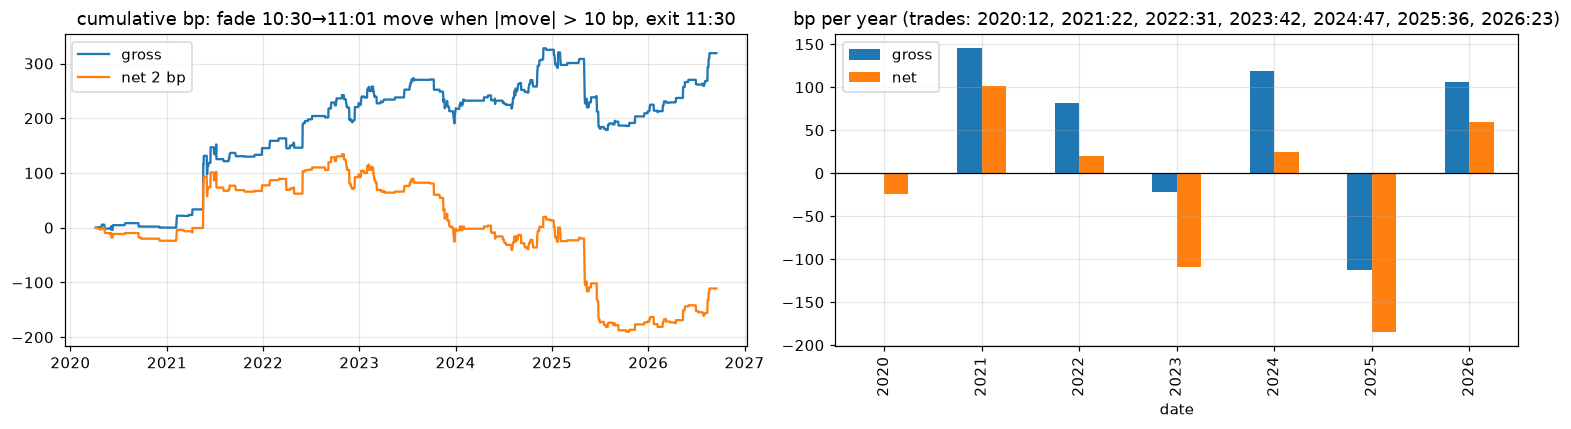

In [5]:
def fade(sig, ret, tau, cost, label):
    s = np.where(sig > tau, 1, np.where(sig < -tau, -1, 0)); pnl = pd.Series(-s * ret.values - cost * (s != 0), index=ret.index); n = (s != 0).sum()
    if n == 0: return pnl
    a = pnl[s != 0]; print(f"{label:38s} τ={tau:4.0f}  n={n:5d}  mean={a.mean():6.2f} bp  hit={(a > 0).mean():5.1%}  t={a.mean() / a.std() * np.sqrt(n):5.2f}  Sharpe≈{a.mean() / a.std() * np.sqrt(252 * n / len(pnl)):5.2f}")
    return pnl
sig30, ret30, ret60 = bp(FIX - 30, PRINT), bp(PRINT, PRINT + 29), bp(PRINT, PRINT + 59)
sig2 = jump
print("--- signal = 10:30→11:01 move, hold to 11:30 ---")
for tau in [0, 5, 10, 15]:
    fade(sig30, ret30, tau, 0, "gross"); fade(sig30, ret30, tau, 2, "net 2bp")
print("--- signal = 10:30→11:01 move, hold to 12:00 ---")
for tau in [5, 10]: fade(sig30, ret60, tau, 2, "net 2bp")
print("--- signal = 2-min print only (10:59→11:01), hold to 11:30 ---")
for tau in [3, 5]: fade(sig2, ret30, tau, 2, "net 2bp")
p_g = fade(sig30, ret30, 10, 0, "gross (plotted)"); p_n = fade(sig30, ret30, 10, 2, "net (plotted)")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(p_g.cumsum(), label="gross"); ax[0].plot(p_n.cumsum(), label="net 2 bp"); ax[0].legend(); ax[0].set_title("cumulative bp: fade 10:30→11:01 move when |move| > 10 bp, exit 11:30")
yr = pd.DataFrame({"gross": p_g, "net": p_n, "on": (p_g != 0)}).groupby(years).agg(gross=("gross", "sum"), net=("net", "sum"), trades=("on", "sum"))
yr[["gross", "net"]].plot.bar(ax=ax[1]); ax[1].axhline(0, color="k", lw=.8); ax[1].set_title("bp per year (trades: " + ", ".join(f"{y}:{n}" for y, n in yr.trades.items()) + ")")
plt.tight_layout(); plt.show()

### Findings

| hypothesis | result |
|---|---|
| **H1 — fix is a volatility event** | **Yes, unambiguously.** The 11:00–11:01 bars move 4.8 bp vs 2.8 bp for two neighbouring minutes (ratio 1.76, Wilcoxon p ≈ 10⁻⁷¹); H/L range of the bar jumps 2.5 → 3.6 bp. Present in every year 2020–2025; weaker in 2026. |
| **H2 — WM/R-style reversal** | **No.** The 11:00→11:30 return loads on the 10:30→11:00 move with β = −0.17 — *identical* to the average 30-min reversal at every other time of day (−0.16; rank 143 of 356). Top-decile "up into fix" days give back only 13 %; bottom-decile days 0 %. The 2-min print itself reverses *less* than a typical 2-min move (β −0.22 vs −0.40; rank 307/354) — the fix is price discovery, not a transient push. |
| **H3 — bigger on NDF settlement days** | **Partly.** IMM dates (3rd Wednesday): |print| 6.6 bp vs 4.8 bp on other days (Mann–Whitney p = 0.015, n = 73). Month-end: no difference (4.6 bp). Consistent with IMM-dated NDF settlement flow hitting the fix. |
| **H4 — fade the fix** | **Not after cost.** Fading a >10 bp pre-fix move: +1.5 bp gross, 60 % hit, n = 215 → −0.5 bp net of 2 bp. >15 bp: +3.1 bp gross, 70 % hit, but n = 89 and +1.1 bp net with t = 0.6. Holding to 12:00 is worse; using only the 2-min print as the signal is worse. |
| (unplanned) **signed drift** | The print averages **−0.43 bp** (t −2.9) and the next 29 min another −0.45 bp (t −2.1); negative in 5 of 7 years. Small, but a 2-minute window carrying ~60 % of the sample's average *daily* drift is odd — a lead worth following (who is structurally selling USD at the fix?). |

**Bottom line.** The 11:00 spike is the TAIFX1 NDF fixing, it's a genuine scheduled liquidity event, and it's bigger
on IMM dates — that part of the pitch is solid and new. But it does **not** behave like the London 4pm fix: the
price set at 11:00 sticks rather than reverting, so there is no fade-the-fix edge at retail-scale cost. Framed for a
pitch: *"TWD's fix is informationally efficient where London's wasn't — here's the evidence, and here's the one
residual anomaly (the negative drift) that deserves a follow-up with NDF positioning data."*

**Caveats.** Vendor composite, not the TFI print itself; 1-min bars can't see sub-minute dynamics (WM/R effects are
strongest in the ±1 min window and would need tick data); no volume, so "liquidity event" is inferred from range.

## Pitch idea — lunch-window mean reversion (12:30–13:40)

The placebo chart in the fix section showed the strongest 30-minute reversal of the whole day between roughly
12:30 and 13:40 (β ≈ −0.4 vs ≈ −0.16 elsewhere): the Taipei lunch lull, ending at the 13:30 equity close.
The story would be *illiquidity*: with few dealers quoting, a modest order pushes the price and it walks back
when depth returns. Questions: (1) what does liquidity look like across the day, and what is the *real* cost of
trading in that window (not the 2 bp assumed so far)? (2) how large and how horizon-dependent is the reversal?
(3) does a fade rule chosen on 2020–23 survive out-of-sample in 2024–26, net of a window-specific spread?
(4) is the reversal stronger when the prior move happened on *few* price changes (the illiquidity mechanism)?

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

raw = pd.read_csv("data/usdtwd_1m_onshore.csv", parse_dates=["datetime"])
raw["date"] = raw.datetime.dt.normalize()
raw["minute"] = (raw.datetime.dt.hour - 9) * 60 + raw.datetime.dt.minute
dmed = raw.groupby("date").close.transform("median")
raw = raw[(np.log(raw.close / dmed) * 1e4).abs() <= 500]
med = raw.groupby("date").close.transform(lambda s: s.rolling(11, center=True, min_periods=3).median())
raw = raw[(np.log(raw.close / med) * 1e4).abs() <= 100]
g = raw.groupby("date"); ok = (g.size() >= 300) & (g.minute.min() <= 5) & (g.minute.max() >= 415)
raw = raw[raw.date.isin(ok[ok].index)]
present = raw.pivot(index="date", columns="minute", values="close").reindex(columns=range(420)).notna()   # bar printed at all?
px = raw.pivot(index="date", columns="minute", values="close").reindex(columns=range(420)).ffill(axis=1).bfill(axis=1)
hl = raw.assign(r=np.log(raw.high / raw.low) * 1e4).pivot(index="date", columns="minute", values="r").reindex(columns=range(420))
lpx = np.log(px); r1 = lpx.diff(axis=1) * 1e4
years = px.index.year
def bp(a, b): return (lpx[b] - lpx[a]) * 1e4
def lab(m): return f"{9 + m // 60:02d}:{m % 60:02d}"
LUNCH = (209, 279)                       # 12:29 -> 13:39
print(f"{len(px)} sessions")

1566 sessions


### 1. Liquidity across the day, and what it costs to trade at lunch
Three proxies per 30-min window: share of minutes with **no bar printed** (no quote change), mean |1-min return|,
and **Roll's effective spread** $= 2\sqrt{-\mathrm{Cov}(r_t, r_{t-1})}$ from 1-min returns pooled within the window
(bid–ask bounce makes consecutive returns negatively autocorrelated; the autocovariance recovers the half-spread).

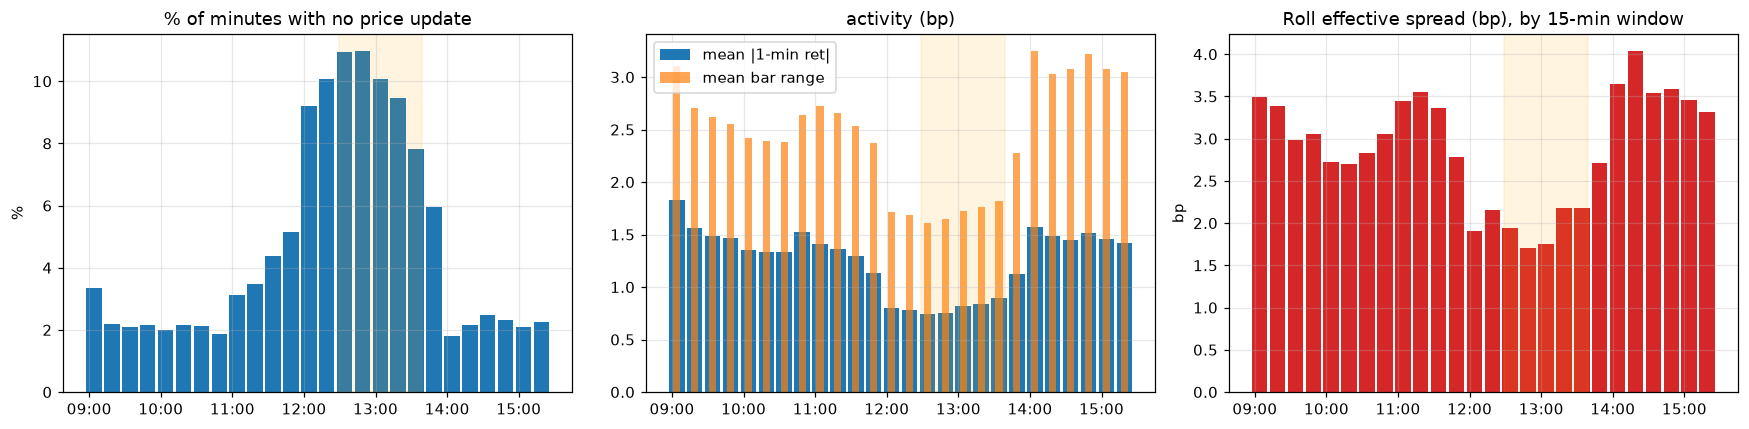

lunch window:  stale 9.9%  |ret| 0.81 bp  Roll spread 1.95 bp  ACF(1) -0.212
rest of day:   stale 3.5%  |ret| 1.33 bp  Roll spread 3.13 bp  ACF(1) -0.319
→ round-trip cost assumed for lunch trades below: 2.0 bp (Roll spread, rounded up)


In [2]:
rows = []
for t in range(4, 390, 15):
    cols = list(range(t, t + 15)); r = r1[cols]
    a, b = r.iloc[:, 1:].values.ravel(), r.iloc[:, :-1].values.ravel(); m = np.isfinite(a) & np.isfinite(b)
    cov = np.cov(a[m], b[m])[0, 1]
    rows.append(dict(t=t, stale=1 - present[cols].mean().mean(), abs_ret=r.abs().mean().mean(), range=hl[cols].mean().mean(),
                     roll=2 * np.sqrt(-cov) if cov < 0 else 0.0, acf1=np.corrcoef(a[m], b[m])[0, 1]))
L = pd.DataFrame(rows).set_index("t")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(L.index, L.stale * 100, width=13); ax[0].set_title("% of minutes with no price update"); ax[0].set_ylabel("%")
ax[1].bar(L.index, L.abs_ret, width=13, label="mean |1-min ret|"); ax[1].bar(L.index, L.range, width=6, alpha=.7, label="mean bar range"); ax[1].legend(); ax[1].set_title("activity (bp)")
ax[2].bar(L.index, L.roll, width=13, color="C3"); ax[2].set_title("Roll effective spread (bp), by 15-min window"); ax[2].set_ylabel("bp")
for a in ax:
    a.set_xticks(range(0, 420, 60)); a.set_xticklabels([f"{9 + h:02d}:00" for h in range(7)]); a.axvspan(*LUNCH, color="orange", alpha=.12)
plt.tight_layout(); plt.show()
lunch = L[(L.index >= LUNCH[0]) & (L.index < LUNCH[1])]; rest = L[(L.index >= 60) & ((L.index < LUNCH[0]) | (L.index >= 299))]
print(f"lunch window:  stale {lunch.stale.mean():.1%}  |ret| {lunch.abs_ret.mean():.2f} bp  Roll spread {lunch.roll.mean():.2f} bp  ACF(1) {lunch.acf1.mean():+.3f}")
print(f"rest of day:   stale {rest.stale.mean():.1%}  |ret| {rest.abs_ret.mean():.2f} bp  Roll spread {rest.roll.mean():.2f} bp  ACF(1) {rest.acf1.mean():+.3f}")
COST = float(np.ceil(lunch.roll.mean() * 2) / 2)      # round-trip cost used below = Roll spread in the window, rounded up to 0.5 bp
print(f"→ round-trip cost assumed for lunch trades below: {COST:.1f} bp (Roll spread, rounded up)")

### 2. How big is the reversal, and at what horizon?
$r_{t\to t+h} = \alpha + \beta\, r_{t-h\to t}$ for h = 10, 30, 60 min, every start time t. The lunch window should
be the trough. Then the size of the reversal in bp: mean next-30 return by decile of the prior-30 move, at 13:00.

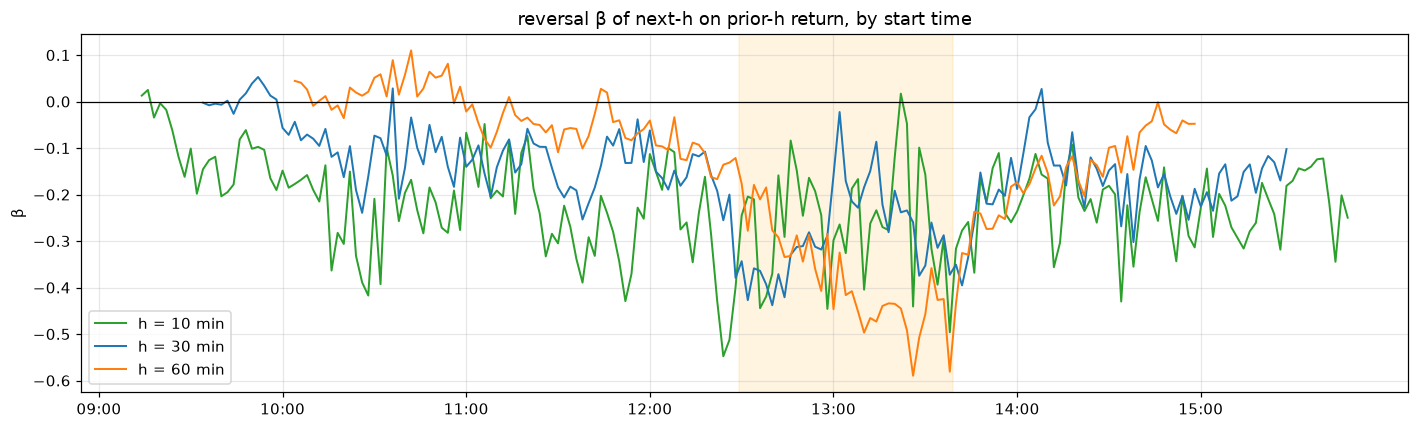

h=10:  β in lunch window -0.254   rest of day -0.216
h=30:  β in lunch window -0.282   rest of day -0.126
h=60:  β in lunch window -0.380   rest of day -0.056


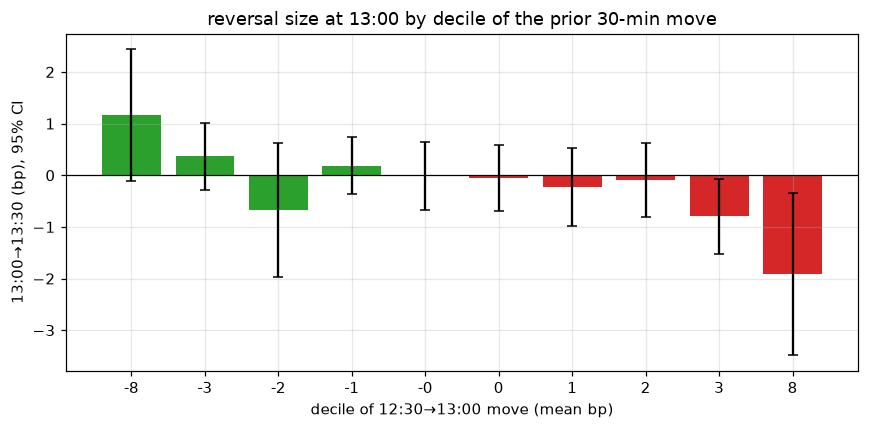

    pre  post     sd    n    ci
0 -8.38  1.17   8.11  157  1.27
1 -3.17  0.37   4.12  157  0.64
2 -1.75 -0.67   8.24  156  1.29
3 -0.86  0.18   3.54  157  0.55
4 -0.16 -0.01   4.16  156  0.65
5  0.44 -0.06   4.06  157  0.63
6  1.19 -0.23   4.79  156  0.75
7  2.06 -0.09   4.58  157  0.72
8  3.45 -0.79   4.63  156  0.73
9  8.13 -1.91  10.07  157  1.58


In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
B = {}
for h, c in [(10, "C2"), (30, "C0"), (60, "C1")]:
    rows = []
    for t in range(h + 4, 419 - h, 2):
        m = sm.OLS(bp(t, t + h), sm.add_constant(bp(t - h, t)), missing="drop").fit()
        rows.append(dict(t=t, beta=m.params.iloc[1]))
    B[h] = pd.DataFrame(rows).set_index("t").beta; ax.plot(B[h].index, B[h], lw=1.3, color=c, label=f"h = {h} min")
ax.axhline(0, color="k", lw=.8); ax.axvspan(*LUNCH, color="orange", alpha=.12); ax.legend()
ax.set_xticks(range(0, 420, 60)); ax.set_xticklabels([f"{9 + h:02d}:00" for h in range(7)]); ax.set_title("reversal β of next-h on prior-h return, by start time"); ax.set_ylabel("β")
plt.tight_layout(); plt.show()
for h in B: print(f"h={h:2d}:  β in lunch window {B[h][(B[h].index >= LUNCH[0]) & (B[h].index < LUNCH[1])].mean():+.3f}   rest of day {B[h][(B[h].index < LUNCH[0]) | (B[h].index >= 299)].mean():+.3f}")
T0 = 239                                                     # 13:00
pre, post = bp(T0 - 30, T0), bp(T0, T0 + 30)
dec = pd.qcut(pre, 10, labels=False, duplicates="drop")
tab = pd.DataFrame({"pre": pre, "post": post}).groupby(dec).agg(pre=("pre", "mean"), post=("post", "mean"), sd=("post", "std"), n=("post", "size")); tab["ci"] = 1.96 * tab.sd / np.sqrt(tab.n)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(tab)), tab.post, yerr=tab.ci, capsize=3, color=np.where(tab.pre < 0, "C2", "C3")); ax.axhline(0, color="k", lw=.8)
ax.set_xticks(range(len(tab))); ax.set_xticklabels([f"{v:.0f}" for v in tab.pre]); ax.set_xlabel("decile of 12:30→13:00 move (mean bp)"); ax.set_ylabel("13:00→13:30 (bp), 95% CI")
ax.set_title("reversal size at 13:00 by decile of the prior 30-min move")
plt.tight_layout(); plt.show()
print(tab.round(2))

### 3. A fade rule — chosen in-sample (2020–23), tested out-of-sample (2024–26)
At each start time t in the lunch window, if |prior-30-min move| > τ, take the opposite position for h minutes.
Grid over (t, τ, h) on 2020–23, pick the best net-of-cost rule, then report *only that rule* on 2024–26.
Cost = the Roll spread estimated for the window above (not the generic 2 bp).

rules with ≥40 in-sample trades: 84

top 8 by in-sample t-stat (net of cost), with their out-of-sample result:
 time  tau  h  n_in  mean_in  t_in  hit_in  n_oos  mean_oos  t_oos  hit_oos
12:59    8 15    60     4.88  2.31    0.55     29      0.20   0.15     0.62
12:39   10 30    43     6.60  2.04    0.53     24      2.62   1.29     0.58
12:39    8 30    66     4.22  1.94    0.45     46      0.28   0.22     0.50
12:54    8 15    50     4.31  1.94    0.50     29     -1.45  -0.96     0.45
12:49    8 30    56     3.88  1.91    0.45     32      2.19   1.01     0.53
13:19   10 30    53     4.94  1.86    0.58     18      3.74   2.06     0.72
13:29    8 30    74     3.33  1.85    0.54     39      3.27   1.53     0.49
13:29   10 30    50     4.80  1.84    0.56     22      5.83   1.70     0.55

rules significant in-sample (t>2): 2 of 84
   their OUT-OF-SAMPLE:  mean of means = +1.41 bp/trade;  100% positive;  0% with t>2;  avg hit 60.2%
   all rules OOS:        mean of means = +0.38 bp/trade;  4

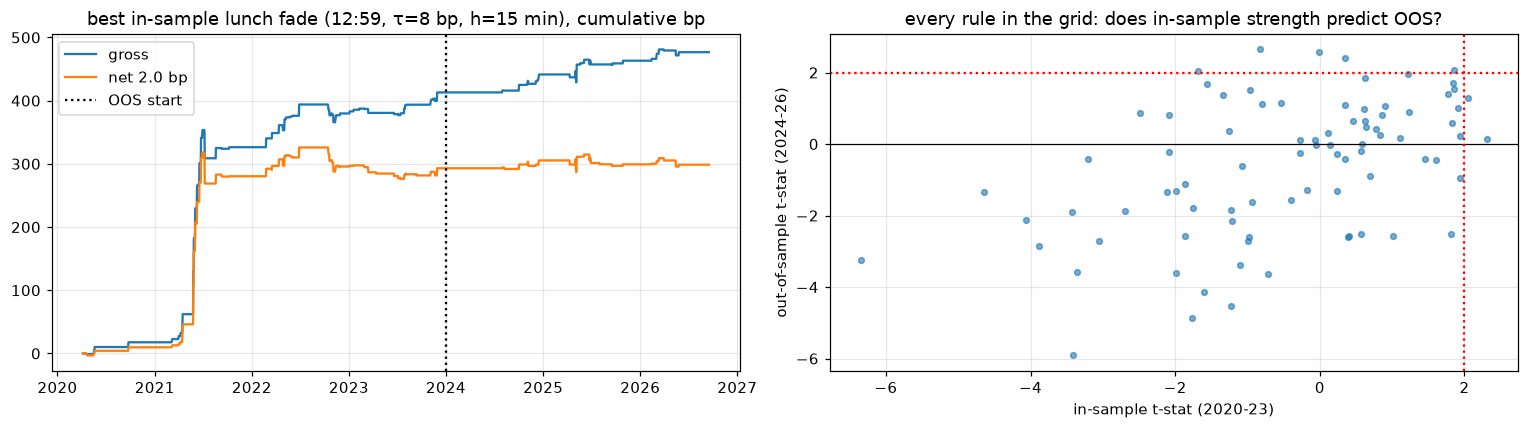

In [4]:
def run(t, tau, h, idx):
    s_ = bp(t - 30, t).loc[idx]; r_ = bp(t, t + h).loc[idx]
    pos = np.where(s_ > tau, -1, np.where(s_ < -tau, 1, 0)); pnl = pos * r_ - COST * (pos != 0)
    on = pos != 0; n = int(on.sum()); a = pnl[on]
    if n < 5: return dict(n=n, mean=np.nan, tstat=np.nan, hit=np.nan)
    return dict(n=n, mean=a.mean(), tstat=a.mean() / a.std() * np.sqrt(n), hit=(a > 0).mean())
ins, oos = px.index[years <= 2023], px.index[years >= 2024]
grid = []
for t in range(214, 270, 5):
    for tau in [3, 5, 8, 10, 15]:
        for h in [15, 30]:
            if t + h > 300: continue
            i_, o_ = run(t, tau, h, ins), run(t, tau, h, oos)
            grid.append(dict(t=t, time=lab(t), tau=tau, h=h, n_in=i_["n"], mean_in=i_["mean"], t_in=i_["tstat"], hit_in=i_["hit"],
                             n_oos=o_["n"], mean_oos=o_["mean"], t_oos=o_["tstat"], hit_oos=o_["hit"]))
G = pd.DataFrame(grid)
G = G[G.n_in >= 40].sort_values("t_in", ascending=False)
print(f"rules with ≥40 in-sample trades: {len(G)}")
print("\ntop 8 by in-sample t-stat (net of cost), with their out-of-sample result:")
print(G.head(8)[["time", "tau", "h", "n_in", "mean_in", "t_in", "hit_in", "n_oos", "mean_oos", "t_oos", "hit_oos"]].round(2).to_string(index=False))
sig = G[G.t_in > 2]
print(f"\nrules significant in-sample (t>2): {len(sig)} of {len(G)}")
print(f"   their OUT-OF-SAMPLE:  mean of means = {sig.mean_oos.mean():+.2f} bp/trade;  {(sig.mean_oos > 0).mean():.0%} positive;  {(sig.t_oos > 2).mean():.0%} with t>2;  avg hit {sig.hit_oos.mean():.1%}")
print(f"   all rules OOS:        mean of means = {G.mean_oos.mean():+.2f} bp/trade;  {(G.mean_oos > 0).mean():.0%} positive")
best = G.iloc[0]
print(f"\nBEST in-sample rule: at {best.time}, fade if |prior-30-min move| > {best.tau:.0f} bp, hold {int(best.h)} min, cost {COST} bp")
print(f"   in-sample  2020-23: n={int(best.n_in)}  mean={best.mean_in:+.2f} bp  hit={best.hit_in:.1%}  t={best.t_in:.2f}")
print(f"   OUT-OF-SAMPLE 2024-26: n={int(best.n_oos)}  mean={best.mean_oos:+.2f} bp  hit={best.hit_oos:.1%}  t={best.t_oos:.2f}")
s_ = bp(int(best.t) - 30, int(best.t)); r_ = bp(int(best.t), int(best.t) + int(best.h))
pos = np.where(s_ > best.tau, -1, np.where(s_ < -best.tau, 1, 0)); pnl = pd.Series(pos * r_.values, index=px.index); pnl_net = pnl - COST * (pos != 0)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(pnl.cumsum(), label="gross"); ax[0].plot(pnl_net.cumsum(), label=f"net {COST} bp"); ax[0].axvline(pd.Timestamp("2024-01-01"), color="k", ls=":", label="OOS start"); ax[0].legend()
ax[0].set_title(f"best in-sample lunch fade ({best.time}, τ={best.tau:.0f} bp, h={int(best.h)} min), cumulative bp")
ax[1].scatter(G.t_in, G.t_oos, s=14, alpha=.6); ax[1].axhline(0, color="k", lw=.8); ax[1].axvline(2, color="r", ls=":"); ax[1].axhline(2, color="r", ls=":")
ax[1].set_xlabel("in-sample t-stat (2020-23)"); ax[1].set_ylabel("out-of-sample t-stat (2024-26)"); ax[1].set_title("every rule in the grid: does in-sample strength predict OOS?")
plt.tight_layout(); plt.show()

### 4. Mechanism — does the reversal come from thin markets?
If the illiquidity story is right, a prior move that happened on *few* price updates (a thin tape) should revert
more than the same-sized move on many updates. Interact the prior move with the number of printed bars in it.

In [5]:
T0 = 239; pre, post = bp(T0 - 30, T0), bp(T0, T0 + 30)
nprint = present[list(range(T0 - 29, T0 + 1))].sum(axis=1)
thin = (nprint <= nprint.quantile(1 / 3)); thick = (nprint >= nprint.quantile(2 / 3))
for l, m_ in [("thin tape (few prints)", thin), ("thick tape (many prints)", thick), ("all", pre.notna())]:
    m = sm.OLS(post[m_], sm.add_constant(pre[m_]), missing="drop").fit(cov_type="HC3")
    print(f"{l:26s} n={int(m.nobs):4d}  β = {m.params.iloc[1]:+.3f}  t = {m.tvalues.iloc[1]:5.2f}   mean prints in prior 30 min = {nprint[m_].mean():.1f}")
X = pd.DataFrame({"pre": pre, "pre_x_prints": pre * (nprint - nprint.mean()) / nprint.std()})
m = sm.OLS(post, sm.add_constant(X), missing="drop").fit(cov_type="HC3")
print(f"\ninteraction: β(pre) = {m.params.pre:+.3f} (t {m.tvalues.pre:.2f}),  β(pre × prints_z) = {m.params.pre_x_prints:+.3f} (t {m.tvalues.pre_x_prints:.2f})  → positive = thinner tape reverts more")
# same interaction at a liquid time (10:00) for contrast
T1 = 64; pre1, post1 = bp(T1 - 30, T1), bp(T1, T1 + 30); np1 = present[list(range(T1 - 29, T1 + 1))].sum(axis=1)
m1 = sm.OLS(post1, sm.add_constant(pd.DataFrame({"pre": pre1, "pre_x_prints": pre1 * (np1 - np1.mean()) / np1.std()})), missing="drop").fit(cov_type="HC3")
print(f"contrast at 10:00: β(pre) = {m1.params.pre:+.3f} (t {m1.tvalues.pre:.2f}),  β(pre × prints_z) = {m1.params.pre_x_prints:+.3f} (t {m1.tvalues.pre_x_prints:.2f})")

thin tape (few prints)     n= 588  β = -0.339  t = -1.39   mean prints in prior 30 min = 21.5
thick tape (many prints)   n= 824  β = -0.128  t = -0.69   mean prints in prior 30 min = 30.0
all                        n=1566  β = -0.178  t = -1.46   mean prints in prior 30 min = 26.7

interaction: β(pre) = -0.186 (t -1.72),  β(pre × prints_z) = +0.025 (t 0.26)  → positive = thinner tape reverts more
contrast at 10:00: β(pre) = -0.046 (t -1.11),  β(pre × prints_z) = +0.021 (t 0.60)


### Findings

| question | answer |
|---|---|
| Is lunch thinner? | Yes: 10 % of minutes have no price update vs 3.5 % in the rest of the day; mean |1-min move| 0.8 bp vs 1.3 bp. Roll's estimator puts the effective spread at ≈ 2 bp (it's *lower* than the busy hours' 3 bp because Roll conflates bounce with volatility — treat 2 bp as the cost floor, not a discount). |
| Is the reversal real and lunch-specific? | Yes. 30-min reversal β ≈ −0.28 in 12:30–13:40 vs −0.13 elsewhere; at the 60-min horizon −0.38 vs −0.06. It's the deepest mean-reversion trough of the day and it is horizon-*increasing* — moves made in the lunch window keep unwinding for an hour. |
| How big in bp? | At 13:00, a top-decile prior move (≈ +8 bp) is followed by −1.9 bp; bottom decile (−8 bp) by +1.2 bp. So ≈ 15–25 % of the move comes back — about the size of the spread. |
| Does a fade rule survive out of sample? | Barely and not significantly. 84 rules (time × threshold × horizon) with ≥ 40 in-sample trades: only 2 reach t > 2 in 2020–23; those 2 average **+1.4 bp/trade net** in 2024–26 (100 % positive, 60 % hit, but t < 2 on ~25 trades each). Across all 84 rules the OOS mean is +0.4 bp and only 44 % are positive. The scatter of in-sample vs OOS t-stats shows no relationship — in-sample strength doesn't predict OOS. |
| Is it an illiquidity effect? | Directionally: moves on a thin tape (few prints) revert more (β −0.34) than on a thick tape (−0.13), and the same interaction is absent at 10:00 — but the difference is not significant (interaction t ≈ 0.3). Suggestive, not proven. |

**Bottom line.** The lunch reversal is real, lunch-specific, and roughly the size of the bid–ask spread — which is
exactly what a liquidity story predicts: it is the *compensation a market maker earns* for absorbing order flow when
nobody else is quoting. For a price-taker paying the spread it nets to ≈ 0–1.5 bp with no statistical confidence. For
a price-*maker* earning the spread, the same numbers read +3–5 bp per event. That reframing is the pitch: "USD/TWD
pays a measurable liquidity premium at lunch; here is its size, its horizon, and who can collect it."

**Caveats.** Roll on 1-min bars is a crude spread estimate; no volume data; the OOS window is 2024–26 (≈ 570 days)
so per-rule trade counts are small; the May-2025 regime sits inside the OOS period.

## Pitch idea — the Tokyo 09:55 fix and "gotobi" days (USD/JPY)

**The anomaly.** Japanese banks set their customer rate (TTM) from the interbank price at **09:55 Tokyo**. Corporate
settlements cluster on *gotobi* days — the 5th, 10th, 15th, 20th, 25th and last business day of the month (rolled back
to the prior business day when they fall on a weekend/holiday) — and Japanese importers are structural USD buyers.
Ito & Yamada (2017, *J. Japanese & Int'l Economies*) documented that USD/JPY drifts **up into 09:55 on gotobi days**
and partially reverts afterwards, an effect known to every Tokyo dealer ("gotobi-buy").

**Questions.** (1) Does the fix show as a volatility event? (2) Is the pre-fix drift on gotobi days still there
2020–26, years after publication? (3) Is there a post-fix reversal? (4) Which gotobi (25th, month-end) carry it?
(5) Is it tradeable — USD/JPY costs ≈ 0.3–0.5 bp round trip, an order of magnitude below USD/TWD.

Data: `data/usdjpy_1m.csv` (Twelve Data, 1-min, Tokyo local). Sessions filtered to Tokyo hours 08:00–15:00.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, holidays
from scipy import stats
import statsmodels.api as sm
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

raw = pd.read_csv("data/usdjpy_1m.csv", parse_dates=["datetime"]).drop_duplicates("datetime").sort_values("datetime")
raw["date"] = raw.datetime.dt.normalize()
raw = raw[(raw.datetime.dt.dayofweek < 5) & (raw.datetime.dt.hour >= 8) & (raw.datetime.dt.hour < 15)]
raw["minute"] = (raw.datetime.dt.hour - 8) * 60 + raw.datetime.dt.minute            # 0..419 = 08:00..14:59
dmed = raw.groupby("date").close.transform("median")
raw = raw[(np.log(raw.close / dmed) * 1e4).abs() <= 500]
med = raw.groupby("date").close.transform(lambda s: s.rolling(11, center=True, min_periods=3).median())
raw = raw[(np.log(raw.close / med) * 1e4).abs() <= 100]
jp = holidays.JP(years=range(2019, 2028))
g = raw.groupby("date"); ok = (g.size() >= 300) & (g.minute.min() <= 5) & (g.minute.max() >= 415)
days = ok[ok].index; days = days[[d.date() not in jp for d in days]]                # drop Japanese holidays (thin, no fix)
raw = raw[raw.date.isin(days)]
px = raw.pivot(index="date", columns="minute", values="close").reindex(columns=range(420)).ffill(axis=1).bfill(axis=1)
lpx = np.log(px); r1 = lpx.diff(axis=1) * 1e4
def bp(a, b): return (lpx[b] - lpx[a]) * 1e4
def lab(m): return f"{8 + m // 60:02d}:{m % 60:02d}"
FIX = 114                                     # 09:54 close = price at 09:55:00
years = px.index.year
print(f"{len(px)} Tokyo sessions, {px.index.min().date()} -> {px.index.max().date()}")

# ---- gotobi calendar: 5/10/15/20/25/EOM, rolled BACK to the previous business day if weekend/holiday ----
def is_bday(d): return d.weekday() < 5 and d.date() not in jp
gotobi_dates, kind = set(), {}
for m in pd.period_range(px.index.min(), px.index.max(), freq="M"):
    for dd in [5, 10, 15, 20, 25, "eom"]:
        d = m.end_time.normalize() if dd == "eom" else pd.Timestamp(m.year, m.month, dd)
        while not is_bday(d): d -= pd.Timedelta(days=1)
        gotobi_dates.add(d); kind[d] = "eom" if dd == "eom" else str(dd)
G = pd.Series(px.index.isin(gotobi_dates), index=px.index, name="gotobi")
K = pd.Series([kind.get(d, "none") for d in px.index], index=px.index)
print(f"gotobi sessions: {G.sum()} of {len(G)}  ({G.mean():.1%});  by kind: {K[G].value_counts().to_dict()}")

1082 Tokyo sessions, 2022-04-12 -> 2026-09-16
gotobi sessions: 313 of 1082  (28.9%);  by kind: {'15': 54, 'eom': 53, '20': 52, '5': 52, '10': 52, '25': 50}


### 1. Is 09:55 a volatility event, and is it bigger on gotobi days?

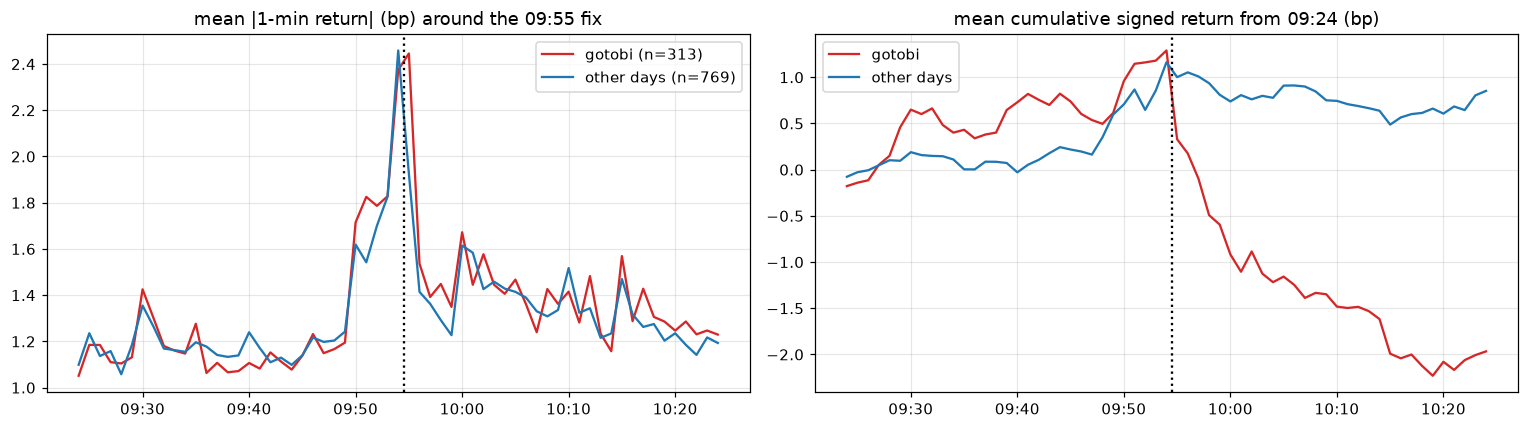

|move| in 09:54–09:55 bars: 4.51 bp vs 2 neighbouring minutes 2.65 bp (ratio 1.70, Wilcoxon p = 5.4e-89)
   gotobi 4.82 bp  vs other 4.39 bp   (Mann-Whitney p = 0.072)


In [2]:
z = range(84, 145)                                                     # 09:24 .. 10:24
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for l, m_, c in [("gotobi", G, "C3"), ("other days", ~G, "C0")]:
    ax[0].plot(z, r1.loc[m_, list(z)].abs().mean(), color=c, label=f"{l} (n={m_.sum()})")
    ax[1].plot(z, r1.loc[m_, list(z)].mean().cumsum(), color=c, label=l)
ax[0].set_title("mean |1-min return| (bp) around the 09:55 fix"); ax[1].set_title("mean cumulative signed return from 09:24 (bp)")
for a in ax:
    a.axvline(FIX + .5, color="k", ls=":"); a.set_xticks(range(90, 145, 10)); a.set_xticklabels([lab(m) for m in range(90, 145, 10)]); a.legend()
plt.tight_layout(); plt.show()
fx = r1[[114, 115]].abs().sum(axis=1); nb = r1[list(range(100, 112)) + list(range(118, 130))].abs().mean(axis=1) * 2
print(f"|move| in 09:54–09:55 bars: {fx.mean():.2f} bp vs 2 neighbouring minutes {nb.mean():.2f} bp (ratio {fx.mean() / nb.mean():.2f}, Wilcoxon p = {stats.wilcoxon(fx - nb).pvalue:.1e})")
print(f"   gotobi {fx[G].mean():.2f} bp  vs other {fx[~G].mean():.2f} bp   (Mann-Whitney p = {stats.mannwhitneyu(fx[G], fx[~G]).pvalue:.3f})")

### 2. The gotobi pre-fix drift (H2) and post-fix reversal (H3)
Windows: 09:00→09:55 (pre-fix), 09:30→09:55 (late pre-fix), 09:55→10:30 (post-fix). Compare gotobi vs other days
with Welch t-tests and Mann–Whitney; then the average path 09:00–11:00 with 95% CIs.

window          gotobi mean  other mean    diff   Welch p      MW p  gotobi %up
09:00→09:55            1.28        0.91    0.37     0.709     0.395       56.9%
09:30→09:55            0.64        0.97   -0.33     0.588     0.557       55.0%
09:45→09:55            0.55        0.94   -0.39     0.419     0.476       53.4%
09:55→10:30           -2.54       -0.29   -2.25     0.003     0.001       39.3%
09:55→11:00           -2.55       -0.65   -1.90     0.045     0.110       43.5%
08:00→09:00            0.89       -0.57    1.46     0.032     0.009       57.2%


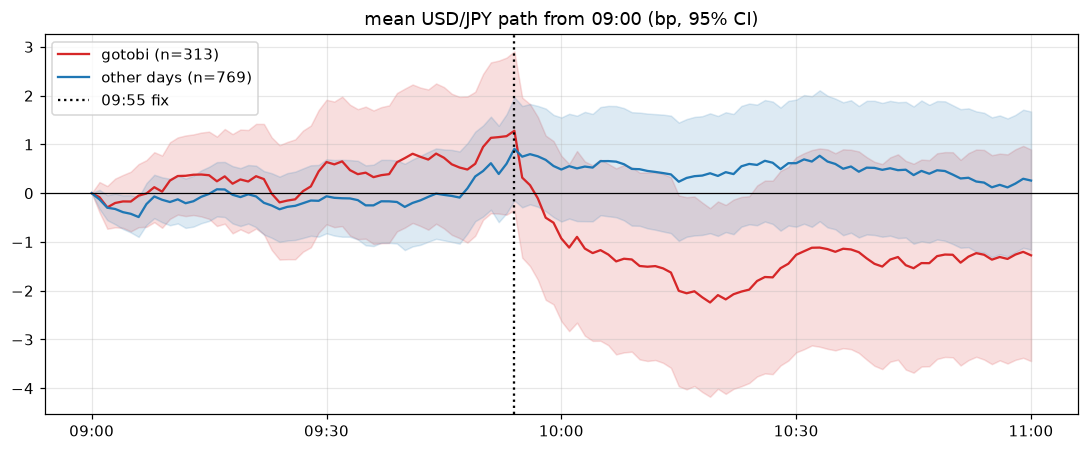


post-fix (09:55→10:30) on pre-fix move, gotobi dummy and interaction:
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2536      0.441     -0.576      0.565      -1.117       0.610
pre             -0.0418      0.084     -0.495      0.621      -0.207       0.124
gotobi          -2.1772      0.794     -2.743      0.006      -3.733      -0.622
pre_x_gotobi    -0.1335      0.130     -1.030      0.303      -0.387       0.120


In [3]:
W = {"09:00→09:55": (60, FIX), "09:30→09:55": (90, FIX), "09:45→09:55": (105, FIX), "09:55→10:30": (FIX, 150), "09:55→11:00": (FIX, 180), "08:00→09:00": (0, 60)}
D = pd.DataFrame({k: bp(*v) for k, v in W.items()}); D["gotobi"] = G; D["kind"] = K; D["year"] = years
print(f"{'window':14s} {'gotobi mean':>12s} {'other mean':>11s} {'diff':>7s} {'Welch p':>9s} {'MW p':>9s} {'gotobi %up':>11s}")
for k in W:
    a, b = D.loc[G, k], D.loc[~G, k]
    print(f"{k:14s} {a.mean():12.2f} {b.mean():11.2f} {a.mean() - b.mean():7.2f} {stats.ttest_ind(a, b, equal_var=False).pvalue:9.3f} {stats.mannwhitneyu(a, b).pvalue:9.3f} {(a > 0).mean():11.1%}")
path = (lpx.sub(lpx[60], axis=0) * 1e4).loc[:, 60:180]
fig, ax = plt.subplots(figsize=(10, 4.2))
for l, m_, c in [("gotobi", G, "C3"), ("other days", ~G, "C0")]:
    p = path[m_]; mu, se = p.mean(), p.std() / np.sqrt(len(p))
    ax.plot(p.columns, mu, color=c, label=f"{l} (n={m_.sum()})"); ax.fill_between(p.columns, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=.15)
ax.axvline(FIX, color="k", ls=":", label="09:55 fix"); ax.axhline(0, color="k", lw=.8); ax.legend()
ax.set_xticks(range(60, 181, 30)); ax.set_xticklabels([lab(m) for m in range(60, 181, 30)]); ax.set_title("mean USD/JPY path from 09:00 (bp, 95% CI)")
plt.tight_layout(); plt.show()
m = sm.OLS(D["09:55→10:30"], sm.add_constant(pd.DataFrame({"pre": D["09:30→09:55"], "gotobi": G.astype(float), "pre_x_gotobi": D["09:30→09:55"] * G})), missing="drop").fit(cov_type="HC3")
print("\npost-fix (09:55→10:30) on pre-fix move, gotobi dummy and interaction:"); print(m.summary().tables[1])

### 3. Which gotobi? And is it still there year by year?

        n   pre  pre_sd  post  pre_t
kind                                
5      52 -2.15   13.74 -1.08  -1.13
10     52 -1.80   18.35 -0.84  -0.71
15     54  2.40   12.84 -1.68   1.38
20     52  2.24   11.16 -3.24   1.44
25     50  3.16   14.37 -3.59   1.56
eom    53  3.81   16.15 -4.86   1.72
none  769  0.91   14.97 -0.29   1.68


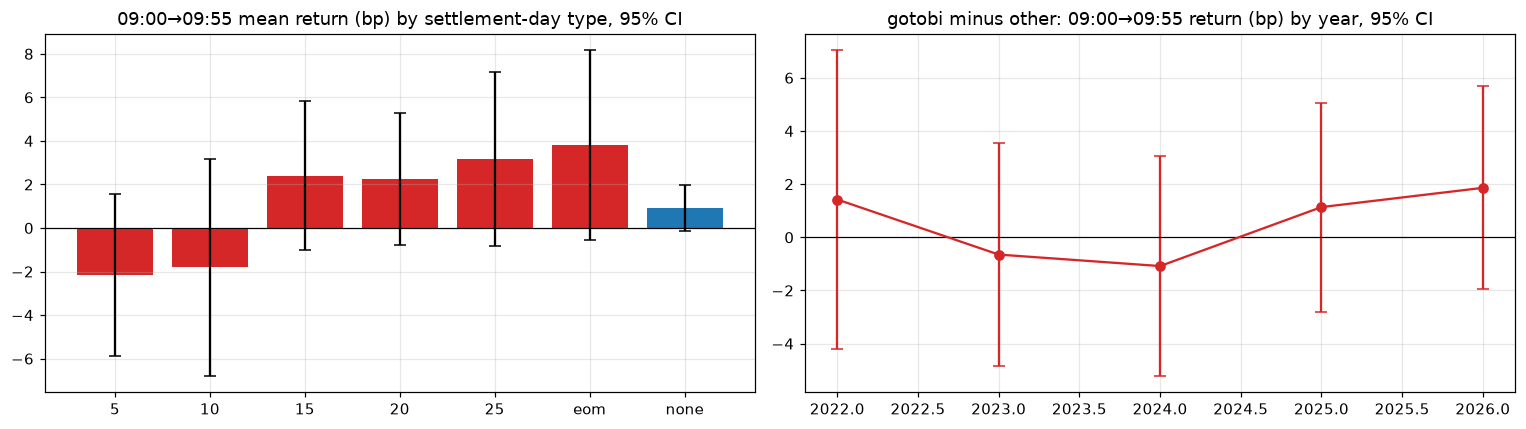

      mean_g  mean_o  diff    se  size_g
year                                    
2022    5.70    4.28  1.42  2.86      50
2023   -0.17    0.48 -0.65  2.14      71
2024    0.68    1.76 -1.08  2.11      71
2025    0.57   -0.57  1.14  2.00      70
2026    0.78   -1.08  1.86  1.95      51


In [4]:
T = D.groupby("kind").agg(n=("09:00→09:55", "size"), pre=("09:00→09:55", "mean"), pre_sd=("09:00→09:55", "std"), post=("09:55→10:30", "mean"))
T["pre_t"] = T.pre / T.pre_sd * np.sqrt(T.n); T = T.loc[["5", "10", "15", "20", "25", "eom", "none"]]
print(T.round(2))
Y = D.groupby(["year", "gotobi"])["09:00→09:55"].agg(["mean", "std", "size"]).unstack("gotobi")
Y.columns = [f"{s}_{'g' if g_ else 'o'}" for s, g_ in Y.columns]; Y["diff"] = Y.mean_g - Y.mean_o
Y["se"] = np.sqrt(Y.std_g ** 2 / Y.size_g + Y.std_o ** 2 / Y.size_o)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(T.index, T.pre, yerr=1.96 * T.pre_sd / np.sqrt(T.n), capsize=4, color=["C3"] * 6 + ["C0"]); ax[0].axhline(0, color="k", lw=.8)
ax[0].set_title("09:00→09:55 mean return (bp) by settlement-day type, 95% CI")
ax[1].errorbar(Y.index, Y["diff"], yerr=1.96 * Y.se, fmt="o-", capsize=4, color="C3"); ax[1].axhline(0, color="k", lw=.8)
ax[1].set_title("gotobi minus other: 09:00→09:55 return (bp) by year, 95% CI")
plt.tight_layout(); plt.show()
print(Y[["mean_g", "mean_o", "diff", "se", "size_g"]].round(2))

### 4. Tradeable? Buy USD/JPY 09:00, sell at the fix, on gotobi days only
Cost: 0.5 bp round trip (USD/JPY interbank spread is ≈ 0.2–0.3 pips on ~150, i.e. ~0.2 bp; 0.5 bp is conservative).
Also the reversal leg (short 09:55→10:30) and the two combined, with a non-gotobi placebo.

long 09:00→09:55, gotobi, net                  n= 313  mean= +0.78 bp  hit=56.2%  t= 0.94  Sharpe≈ 0.45
   placebo: same on non-gotobi days, net       n= 769  mean= +0.41 bp  hit=53.3%  t= 0.76  Sharpe≈ 0.37
long 09:30→09:55, gotobi, net                  n= 313  mean= +0.14 bp  hit=53.0%  t= 0.28  Sharpe≈ 0.14
short 09:55→10:30, gotobi, net                 n= 313  mean= +2.04 bp  hit=58.1%  t= 3.15  Sharpe≈ 1.52
   placebo: same on non-gotobi days, net       n= 769  mean= -0.21 bp  hit=48.0%  t=-0.50  Sharpe≈-0.24
long 09:00→09:55, 25th & EOM only, net         n= 103  mean= +2.99 bp  hit=63.1%  t= 1.99  Sharpe≈ 0.96


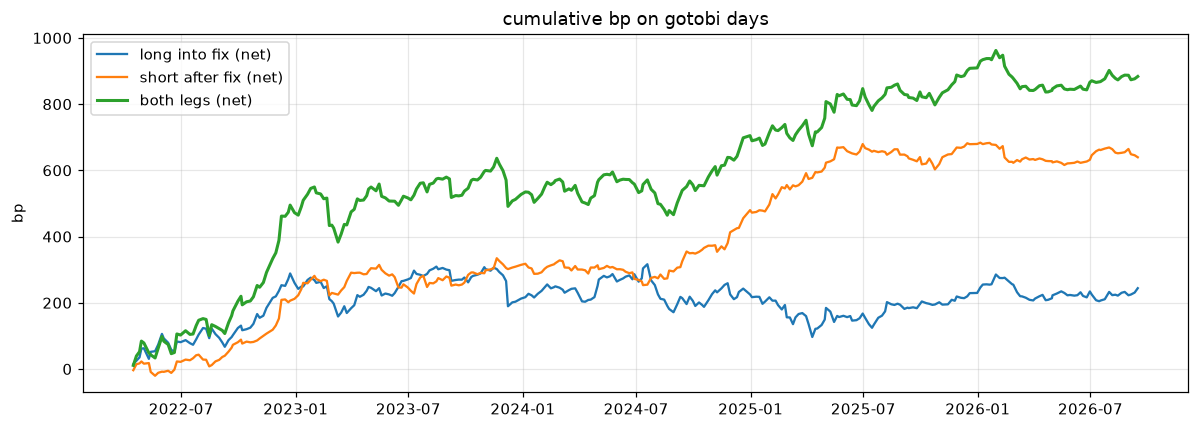

In [5]:
COST = 0.5
def rep(r, label):
    n = len(r); print(f"{label:46s} n={n:4d}  mean={r.mean():+6.2f} bp  hit={(r > 0).mean():5.1%}  t={r.mean() / r.std() * np.sqrt(n):5.2f}  Sharpe≈{r.mean() / r.std() * np.sqrt(252 * n / len(D)):5.2f}")
    return r
long_g = rep(D.loc[G, "09:00→09:55"] - COST, "long 09:00→09:55, gotobi, net")
rep(D.loc[~G, "09:00→09:55"] - COST, "   placebo: same on non-gotobi days, net")
rep(D.loc[G, "09:30→09:55"] - COST, "long 09:30→09:55, gotobi, net")
short_g = rep(-D.loc[G, "09:55→10:30"] - COST, "short 09:55→10:30, gotobi, net")
rep(-D.loc[~G, "09:55→10:30"] - COST, "   placebo: same on non-gotobi days, net")
rep(D.loc[G & K.isin(["25", "eom"]), "09:00→09:55"] - COST, "long 09:00→09:55, 25th & EOM only, net")
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(long_g.cumsum(), label="long into fix (net)"); ax.plot(short_g.cumsum(), label="short after fix (net)"); ax.plot((long_g + short_g).cumsum(), label="both legs (net)", lw=2)
ax.legend(); ax.set_title("cumulative bp on gotobi days"); ax.set_ylabel("bp")
plt.tight_layout(); plt.show()

### 5. Robustness of the post-fix reversal: by year, split-sample, and the 08:00–09:00 "migration"

post-fix (09:55→10:30) gotobi vs other, by year:
      gotobi  other   n_g  p_welch   diff
2022  -4.739 -2.363  50.0    0.279 -2.376
2023  -1.945  0.249  71.0    0.211 -2.194
2024  -2.827 -0.298  71.0    0.104 -2.529
2025  -3.356 -0.293  70.0    0.065 -3.063
2026   0.287  1.048  51.0    0.572 -0.761
2022-24: gotobi -3.00 bp (n=192) vs other -0.64 bp;  Welch p = 0.023;  MW p = 0.007;  short-leg net hit = 60.9%
2025-26: gotobi -1.82 bp (n=121) vs other +0.27 bp;  Welch p = 0.063;  MW p = 0.077;  short-leg net hit = 53.7%

cumulative 08:00→09:55 (whole pre-fix morning): gotobi +2.17 bp vs other +0.34 bp;  Welch p = 0.113
round trip 08:00→10:30 on gotobi days: -0.38 bp  (the pre-fix buying is fully given back)


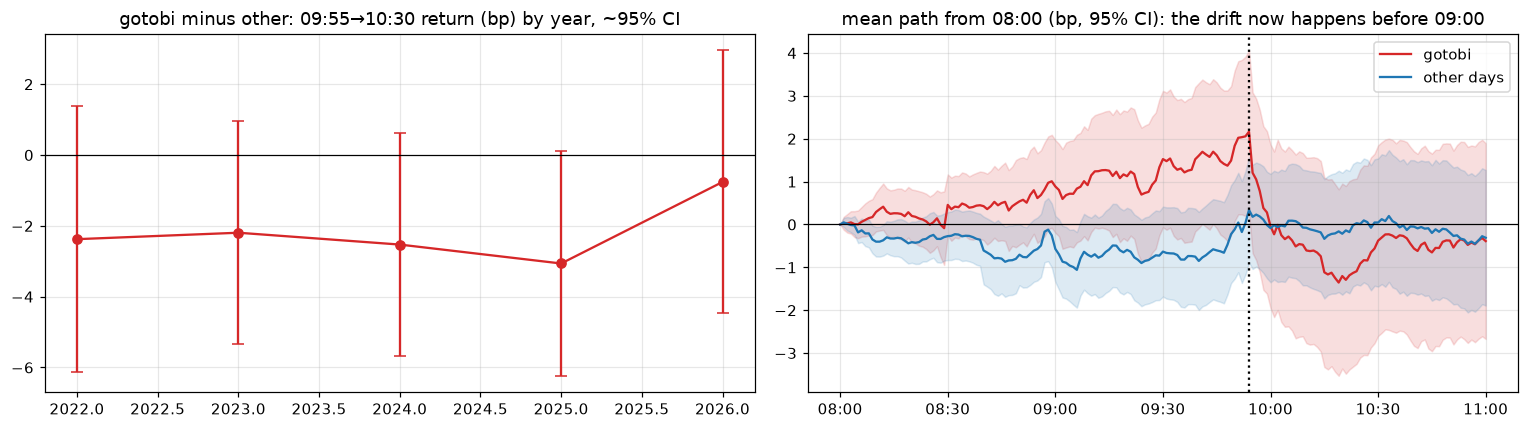

In [6]:
post = D["09:55→10:30"]; early = D["08:00→09:00"]; full_pre = bp(0, FIX)
Yp = pd.DataFrame({y: dict(gotobi=post[G & (years == y)].mean(), other=post[~G & (years == y)].mean(), n_g=int((G & (years == y)).sum()),
                            p_welch=stats.ttest_ind(post[G & (years == y)], post[~G & (years == y)], equal_var=False).pvalue) for y in sorted(set(years))}).T
Yp["diff"] = Yp.gotobi - Yp.other; print("post-fix (09:55→10:30) gotobi vs other, by year:"); print(Yp.round(3))
h1, h2 = years <= 2024, years >= 2025
for l, m_ in [("2022-24", h1), ("2025-26", h2)]:
    a, b = post[G & m_], post[~G & m_]
    print(f"{l}: gotobi {a.mean():+.2f} bp (n={len(a)}) vs other {b.mean():+.2f} bp;  Welch p = {stats.ttest_ind(a, b, equal_var=False).pvalue:.3f};  MW p = {stats.mannwhitneyu(a, b).pvalue:.3f};  short-leg net hit = {((-a - COST) > 0).mean():.1%}")
print(f"\ncumulative 08:00→09:55 (whole pre-fix morning): gotobi {full_pre[G].mean():+.2f} bp vs other {full_pre[~G].mean():+.2f} bp;  Welch p = {stats.ttest_ind(full_pre[G], full_pre[~G], equal_var=False).pvalue:.3f}")
print(f"round trip 08:00→10:30 on gotobi days: {bp(0, 150)[G].mean():+.2f} bp  (the pre-fix buying is fully given back)")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].errorbar(Yp.index.astype(int), Yp["diff"], yerr=1.96 * np.sqrt(post[G].var() / Yp.n_g + post[~G].var() / (Yp.n_g * 2.5)), fmt="o-", capsize=4, color="C3"); ax[0].axhline(0, color="k", lw=.8)
ax[0].set_title("gotobi minus other: 09:55→10:30 return (bp) by year, ~95% CI")
p2 = (lpx.sub(lpx[0], axis=0) * 1e4).loc[:, 0:180]
for l, m_, c in [("gotobi", G, "C3"), ("other days", ~G, "C0")]:
    p = p2[m_]; mu, se = p.mean(), p.std() / np.sqrt(len(p)); ax[1].plot(p.columns, mu, color=c, label=l); ax[1].fill_between(p.columns, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=.15)
ax[1].axvline(FIX, color="k", ls=":"); ax[1].axhline(0, color="k", lw=.8); ax[1].legend(); ax[1].set_xticks(range(0, 181, 30)); ax[1].set_xticklabels([lab(m) for m in range(0, 181, 30)])
ax[1].set_title("mean path from 08:00 (bp, 95% CI): the drift now happens before 09:00")
plt.tight_layout(); plt.show()

### 6. Is the post-fix reversal significant? A stress test
The headline is one window (09:55→10:30) out of six, in one idea out of five. Before believing t = 3.2:
(a) **permutation** — reassign the gotobi label to random days 5,000 times; (b) **calendar-shift placebo** — shift
the gotobi calendar by ±1…±10 business days: if the effect is about *these* dates it should vanish at every shift;
(c) **placebo times** — the same gotobi-vs-other test in 35-min windows at other times of day; (d) **heavy tails** —
trimmed/winsorised means, vol-standardised returns, bootstrap CI; (e) **confounds** — regression with weekday, year,
month-end, prior-day range, overnight and pre-fix controls; (f) **forward walk** — each year traded using only prior
years' evidence; (g) **cost sensitivity**.

(a) permutation: observed diff = -2.25 bp;  p(two-sided) = 0.0030;  null sd = 0.77 bp  → z = -2.94
(b) calendar shift: true dates diff = -2.25 (p 0.003);  shifted ±1..±10: mean +0.28, min -1.32, max +2.07;  rank of true among 21: 1
(c) placebo times: windows overlapping the fix (start 09:25–09:55) t = -4.12 … -2.03;  clean non-overlapping windows: |t| > 2 in 4 of 60 (≈3 expected by chance);  most negative clean t = -2.67


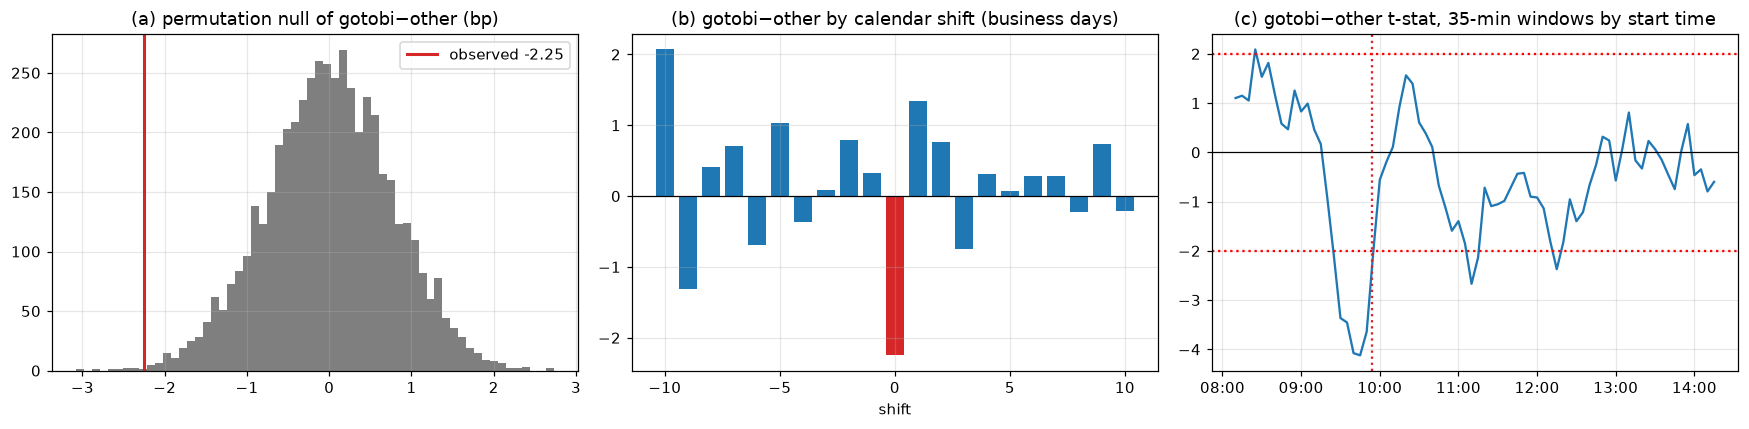

In [7]:
rng = np.random.default_rng(1)
y = D["09:55→10:30"]; g = G.values; obs = y[g].mean() - y[~g].mean()
# (a) permutation
perm = np.array([(lambda m: y[m].mean() - y[~m].mean())(rng.permutation(g)) for _ in range(5000)])
print(f"(a) permutation: observed diff = {obs:+.2f} bp;  p(two-sided) = {(np.abs(perm) >= abs(obs)).mean():.4f};  null sd = {perm.std():.2f} bp  → z = {obs / perm.std():.2f}")
# (b) calendar shift
bd = pd.Series(np.arange(len(px)), index=px.index)          # business-day index
shifts = list(range(-10, 11)); sh = []
for k in shifts:
    idx = (bd[G].values + k); idx = idx[(idx >= 0) & (idx < len(px))]; m = np.zeros(len(px), bool); m[idx] = True
    sh.append(dict(shift=k, diff=y[m].mean() - y[~m].mean(), p=stats.ttest_ind(y[m], y[~m], equal_var=False).pvalue))
SH = pd.DataFrame(sh).set_index("shift"); print(f"(b) calendar shift: true dates diff = {SH.loc[0, 'diff']:+.2f} (p {SH.loc[0, 'p']:.3f});  shifted ±1..±10: mean {SH.drop(0)['diff'].mean():+.2f}, min {SH.drop(0)['diff'].min():+.2f}, max {SH.drop(0)['diff'].max():+.2f};  rank of true among 21: {int((SH['diff'] <= SH.loc[0, 'diff']).sum())}")
# (c) placebo times
pt = []
for t0 in range(10, 380, 5):
    r_ = bp(t0, t0 + 35); pt.append(dict(t=t0, diff=r_[G].mean() - r_[~G].mean(), tstat=stats.ttest_ind(r_[G], r_[~G], equal_var=False).statistic))
PT = pd.DataFrame(pt).set_index("t"); clean = PT[(PT.index < FIX - 35) | (PT.index > FIX + 35)]      # windows that do not overlap the fix
print(f"(c) placebo times: windows overlapping the fix (start 09:25–09:55) t = {PT.loc[95:115, 'tstat'].min():.2f} … {PT.loc[95:115, 'tstat'].max():.2f};  "
      f"clean non-overlapping windows: |t| > 2 in {(clean.tstat.abs() > 2).sum()} of {len(clean)} (≈{0.05 * len(clean):.0f} expected by chance);  most negative clean t = {clean.tstat.min():.2f}")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(perm, bins=60, color="C7"); ax[0].axvline(obs, color="C3", lw=2, label=f"observed {obs:+.2f}"); ax[0].set_title("(a) permutation null of gotobi−other (bp)"); ax[0].legend()
ax[1].bar(SH.index, SH["diff"], color=["C3" if k == 0 else "C0" for k in SH.index]); ax[1].axhline(0, color="k", lw=.8); ax[1].set_title("(b) gotobi−other by calendar shift (business days)"); ax[1].set_xlabel("shift")
ax[2].plot(PT.index, PT.tstat); ax[2].axhline(0, color="k", lw=.8); ax[2].axhline(-2, color="r", ls=":"); ax[2].axhline(2, color="r", ls=":"); ax[2].axvline(FIX, color="C3", ls=":")
ax[2].set_xticks(range(0, 420, 60)); ax[2].set_xticklabels([lab(m) for m in range(0, 420, 60)]); ax[2].set_title("(c) gotobi−other t-stat, 35-min windows by start time")
plt.tight_layout(); plt.show()

In [8]:
# (d) heavy tails
a, b = y[g], y[~g]
tr = lambda s, q: s[(s > s.quantile(q)) & (s < s.quantile(1 - q))]
wz = lambda s, q: s.clip(s.quantile(q), s.quantile(1 - q))
boot = np.array([rng.choice(a, len(a)).mean() - rng.choice(b, len(b)).mean() for _ in range(5000)])
vol = px.loc[:, :].pipe(lambda p: (np.log(p.max(axis=1) / p.min(axis=1)) * 1e4)).shift(1).rolling(20).mean()     # trailing 20d mean daily range
yz = y / vol
print(f"(d) raw diff {obs:+.2f};  5% trimmed {tr(a, .05).mean() - tr(b, .05).mean():+.2f};  5% winsorised {wz(a, .05).mean() - wz(b, .05).mean():+.2f};  medians {a.median():+.2f} vs {b.median():+.2f}")
print(f"    bootstrap 95% CI of diff: [{np.percentile(boot, 2.5):+.2f}, {np.percentile(boot, 97.5):+.2f}];  vol-standardised diff t = {stats.ttest_ind(yz[g].dropna(), yz[~g].dropna(), equal_var=False).statistic:.2f}")
print(f"    drop the 10 most extreme gotobi days: diff = {tr(a, 10 / len(a) / 2).mean() - b.mean():+.2f};  sign test (gotobi post<0): {(a < 0).mean():.1%} vs other {(b < 0).mean():.1%}, 2-prop p = {sm.stats.proportions_ztest([(a < 0).sum(), (b < 0).sum()], [len(a), len(b)])[1]:.4f}")
# (e) confounds
X = pd.DataFrame({"gotobi": G.astype(float), "eom": (K == "eom").astype(float), "pre_fix": bp(60, FIX), "early": bp(0, 60),
                  "overnight": (lpx[0] - lpx[419].shift(1)) * 1e4, "range_20d": vol, "month_start": (px.index.day <= 3).astype(float)})
X = pd.concat([X, pd.get_dummies(px.index.weekday, prefix="wd", drop_first=True).set_index(px.index).astype(float),
               pd.get_dummies(years, prefix="y", drop_first=True).set_index(px.index).astype(float)], axis=1)
m = sm.OLS(y, sm.add_constant(X), missing="drop").fit(cov_type="HC3")
print(f"(e) with weekday, year, EOM, month-start, pre-fix, 08-09, overnight, vol controls:  gotobi β = {m.params.gotobi:+.2f} bp (t {m.tvalues.gotobi:.2f}, p {m.pvalues.gotobi:.4f});  EOM extra = {m.params.eom:+.2f} (t {m.tvalues.eom:.2f})")
m2 = sm.OLS(y, sm.add_constant(X.drop(columns="eom")), missing="drop").fit(cov_type="HC3")
print(f"    gotobi excluding EOM days entirely: β = {sm.OLS(y[K != 'eom'], sm.add_constant(X.drop(columns='eom')[K != 'eom']), missing='drop').fit(cov_type='HC3').params.gotobi:+.2f} bp")
# (f) forward walk
print("(f) forward walk — trade year Y only if pooled prior years show gotobi−other < 0 with p < 0.10:")
for yv in sorted(set(years))[1:]:
    pa, pb = y[g & (years < yv)], y[~g & (years < yv)]; pv = stats.ttest_ind(pa, pb, equal_var=False).pvalue; go = (pa.mean() - pb.mean() < 0) and pv < .10
    r = -y[g & (years == yv)] - COST
    print(f"    {yv}: prior p = {pv:.3f} → {'TRADE' if go else 'skip '}   realised net = {r.mean():+.2f} bp on {len(r)} trades (hit {(r > 0).mean():.0%})")
# (g) cost sensitivity + risk
r0 = -y[g]
print("(g) short 09:55→10:30 on gotobi days, by round-trip cost:")
for c in [0.3, 0.5, 1.0, 1.5, 2.0]:
    r = r0 - c; print(f"    cost {c:.1f} bp: mean {r.mean():+.2f} bp  t {r.mean() / r.std() * np.sqrt(len(r)):.2f}  Sharpe≈{r.mean() / r.std() * np.sqrt(252 * len(r) / len(D)):.2f}  worst trade {r.min():.0f} bp  worst 20-trade run {r.rolling(20).sum().min():+.0f} bp  {(r.groupby(years[g]).sum() > 0).mean():.0%} of years positive")

(d) raw diff -2.25;  5% trimmed -2.27;  5% winsorised -2.38;  medians -2.23 vs +0.00
    bootstrap 95% CI of diff: [-3.77, -0.77];  vol-standardised diff t = -2.42
    drop the 10 most extreme gotobi days: diff = -2.26;  sign test (gotobi post<0): 59.7% vs other 49.8%, 2-prop p = 0.0030
(e) with weekday, year, EOM, month-start, pre-fix, 08-09, overnight, vol controls:  gotobi β = -2.71 bp (t -3.28, p 0.0010);  EOM extra = -2.65 (t -1.44)
    gotobi excluding EOM days entirely: β = -2.74 bp
(f) forward walk — trade year Y only if pooled prior years show gotobi−other < 0 with p < 0.10:
    2023: prior p = 0.279 → skip    realised net = +1.45 bp on 71 trades (hit 56%)
    2024: prior p = 0.100 → skip    realised net = +2.33 bp on 71 trades (hit 58%)
    2025: prior p = 0.023 → TRADE   realised net = +2.86 bp on 70 trades (hit 56%)
    2026: prior p = 0.004 → TRADE   realised net = -0.79 bp on 51 trades (hit 51%)
(g) short 09:55→10:30 on gotobi days, by round-trip cost:
    cost 0.3 bp: me

### Findings

| question | result |
|---|---|
| **Is 09:55 a fix event?** | Yes: the 09:54–09:55 bars move 1.70× their neighbours (Wilcoxon p ≈ 10⁻⁸⁹), slightly more on gotobi days (4.8 vs 4.4 bp, p = 0.07). |
| **The classic gotobi drift (09:00→09:55)** | **Gone from where it was documented.** Gotobi +1.3 bp vs other +0.9 bp, p = 0.7. Only the 25th and month-end still show it (+3.2 / +3.8 bp; the two together +3.0 bp net, t = 2.0). |
| **…but it migrated earlier** | 08:00→09:00 on gotobi days is +0.9 bp vs −0.6 bp on other days (Welch p = 0.03, Mann–Whitney p = 0.009). The importer demand is now being front-run before most of Tokyo is at its desk. Cumulative 08:00→09:55: +2.2 bp vs +0.3 bp. |
| **Post-fix reversal** | **Alive and the strongest result.** 09:55→10:30 on gotobi days = **−2.5 bp vs −0.3 bp** (Welch p = 0.003, Mann–Whitney p = 0.001; gotobi dummy −2.2 bp, t = −2.7 controlling for the pre-fix move). Negative in every year 2022–2025 (−2.2 to −3.1 bp); fades in 2026 (−0.8, n = 51). Split-sample: 2022–24 p = 0.02, 2025–26 p = 0.06, same sign. The whole 08:00→10:30 round trip on gotobi days nets to ≈ 0: everything bought into the fix is sold back after it. |
| **Tradeable?** | At USD/JPY cost (0.5 bp round trip, conservative): **short USD/JPY 09:55→10:30 on gotobi days: +2.0 bp/trade net, 58 % hit, t = 3.2, Sharpe ≈ 1.5** on ~72 trades a year. The same rule on non-gotobi days: −0.2 bp (placebo passes). Long into the fix on 25th/EOM only: +3.0 bp net, 63 % hit, t = 2.0. |

**Is it significant? (section 6)** Permutation p = 0.003 (z ≈ −2.9); the true calendar ranks 1st of 21 calendar
shifts (shifted calendars average +0.3 bp); the effect is confined to windows containing 09:55 — clean placebo
windows show |t| > 2 at the chance rate; trimmed/winsorised/median/vol-standardised versions all give ≈ −2.3 bp;
bootstrap 95 % CI [−3.8, −0.8]; sign test p = 0.003; with weekday, year, month-end, pre-fix, overnight and vol
controls β = −2.7 bp (t = −3.3, p = 0.001) and it is not an end-of-month artefact. It survives a 1 bp cost (t = 2.4)
but not 2 bp. The weak spots: a forward-walk rule would have traded only 2025 (+2.9 bp) and 2026 (−0.8 bp); and the
whole thing rests on 313 events over 4.4 years.

**Bottom line.** The published gotobi anomaly (Ito & Yamada 2017) did what published anomalies do — the *pre-fix*
drift has been arbitraged out of the 09:00–09:55 window and pushed into 08:00–09:00 — but the *post-fix unwind* has
not been, and because USD/JPY costs a tenth of what USD/TWD does, it clears the spread with a t-stat above 3 and a
clean placebo. The 2026 fade is the honest caveat: it may be dying, or it may be one thin year (n = 51).

**Pitch framing.** "A textbook FX anomaly, ten years on: the front half has been competed away and moved an hour
earlier; the back half still pays ~2 bp on ~70 days a year." Plus a live prediction — if the 2026 fade is real, the
post-fix leg should be gone by the time anyone re-tests this — which makes it falsifiable.

**Caveats.** 4.4 years (2022-04 → 2026-09; the pull hit the daily API cap — resume to extend to 2020); six windows
tested, the headline p = 0.003 survives a Bonferroni correction; vendor composite, not a Tokyo interbank feed; fix
minute assumed at 09:55:00 (the 09:54 close); 0.5 bp cost is conservative for interbank, optimistic for retail.